In [5]:
!pip -q install ultralytics

import os, re, json, copy, math, warnings, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import GroupKFold, KFold, cross_val_predict
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings("ignore")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")

# ---- paths: edit these two if yours differ -------------------------------
DRIVE      = "/content/drive/MyDrive/KSU/Research/SmartWeight"
DATA_FULL  = "/content/cow_dataset"          # UNCROPPED images (needed for A/C/D/F)
COW_CSV    = f"{DRIVE}/cow.csv"
DATASET_CSV = f"{DATA_FULL}/cow_weight_dataset.csv"

# ---- experiment budget ---------------------------------------------------
IMG_SIZE   = 384 # Increased from 320 to 384 for better GPU utilization
FOLDS      = 3      # screening; raise to 5 for the final number
EPOCHS     = 40     # screening; raise to 80 for the final number
BATCH_SIZE = 128 # Increased from 16 to 128 for better GPU utilization
LR         = 3e-4
PATIENCE   = 10
SEED       = 42

torch.manual_seed(SEED); np.random.seed(SEED)

device: cuda | NVIDIA A100-SXM4-80GB


In [7]:
import pandas as pd
import os

cow_df = pd.read_csv('/content/drive/MyDrive/KSU/Research/SmartWeight/cow.csv')

# Standardize the 'ID' column in cow_df to uppercase 'CXXX' format for consistent matching
cow_df['ID'] = cow_df['ID'].str.upper()

# Create a dictionary for quick weight lookup
weight_map = cow_df.set_index('ID')['Weight'].to_dict()

# Prepare a list to store the new dataset rows
dataset_rows = []

# Corrected base_yolo_dir to point to the actual unzipped content directory
base_yolo_dir = DATA_FULL # Changed from '/content/unzipped_project'
categories = ['train', 'valid', 'test']

for category in categories:
    # Corrected path: 'images' is not a sub-directory within train/valid/test
    images_dir = os.path.join(base_yolo_dir, category, 'images') # Corrected to include 'images' subdirectory
    if not os.path.exists(images_dir):
        print(f"Warning: Image directory not found for {category}: {images_dir}")
        continue

    for filename in os.listdir(images_dir):
        if filename.endswith(('.jpg', '.jpeg', '.png')):
            full_path = os.path.join(images_dir, filename)

            extracted_id_raw = filename.split('_')[0]

            # Remove augmentation suffix if present (e.g., 'C139-1' -> 'C139')
            if '-' in extracted_id_raw:
                extracted_id_temp = extracted_id_raw.split('-')[0]
            else:
                extracted_id_temp = extracted_id_raw

            extracted_id_temp = extracted_id_temp.upper()

            # Attempt to standardize to 'CXXX' format where XXX is a 3-digit number
            extracted_id = None
            if extracted_id_temp.startswith('C'):
                numeric_part_str = extracted_id_temp[1:]
                if numeric_part_str.isdigit():
                    # Convert to int, then format as 3 digits (e.g., '0074' -> '74' -> '074')
                    numeric_value = int(numeric_part_str)
                    extracted_id = 'C' + str(numeric_value).zfill(3)
                else:
                    # If it starts with C but remainder is not digits, keep as is (unlikely to match)
                    extracted_id = extracted_id_temp
                    print(f"Warning: ID part after 'C' is not numeric for '{extracted_id_raw}'. Using '{extracted_id}' for lookup.")
            elif extracted_id_temp.isdigit():
                # Only digits, e.g., '110', '74' -> 'C110', 'C074'
                numeric_value = int(extracted_id_temp)
                extracted_id = 'C' + str(numeric_value).zfill(3)
            else:
                # Completely unexpected format, e.g., 'BRAHMAN'
                extracted_id = extracted_id_temp
                print(f"Warning: Unexpected ID format '{extracted_id_raw}'. Not starting with 'C' and not pure digits. Using '{extracted_id}' for lookup.")

            # Now use 'extracted_id' for lookup
            if extracted_id:
                weight = weight_map.get(extracted_id)

                if weight is not None:
                    dataset_rows.append({
                        'ID': extracted_id, # Use the standardized ID for consistency
                        'path': full_path,
                        'weight': weight,
                        'category': category
                    })
                else:
                    print(f"Warning: No weight found for standardized ID {extracted_id} (derived from original file ID '{extracted_id_raw}' in file '{filename}') in cow_df.")

# Create the new DataFrame
new_dataset_df = pd.DataFrame(dataset_rows)

# Merge 'L', 'Height', and 'Age' from cow_df into new_dataset_df
# Drop redundant _Height_ and _Age_ columns from cow_df before merging if they exist
columns_to_merge = ['ID', 'L', 'Height', 'Age']

# Ensure 'cow_df' only contains necessary columns for merging to avoid duplicates
cow_df_for_merge = cow_df[columns_to_merge].copy()

# Check if new_dataset_df is empty before merging
if not new_dataset_df.empty:
    new_dataset_df = pd.merge(new_dataset_df, cow_df_for_merge, on='ID', how='left')
else:
    print("Warning: new_dataset_df is empty. Skipping merge with cow_df_for_merge.")


# Display the first few rows of the new dataset with added columns
display(new_dataset_df.head())

# Save the new dataset to a CSV file
output_csv_path = '/content/cow_weight_dataset.csv'
new_dataset_df.to_csv(output_csv_path, index=False)

print(f"New dataset saved to {output_csv_path}")

,ID,path,weight,category,L,Height,Age
0,C030,/content/cow_dataset/train/images/c0030-1_jpg....,399.200,train,170.0,140.0,3Y
1,C133,/content/cow_dataset/train/images/C133-1_jpg.r...,387.492,train,168.0,144.0,5Y
2,C087,/content/cow_dataset/train/images/c0087_jpg.rf...,416.762,train,173.0,142.0,5Y
3,C077,/content/cow_dataset/train/images/c0077_jpg.rf...,340.660,train,160.0,160.0,2.6Y
4,C075,/content/cow_dataset/train/images/c0075-1_jpg....,323.098,train,157.0,140.0,3Y


New dataset saved to /content/cow_weight_dataset.csv


In [8]:
cp '/content/cow_weight_dataset.csv' '/content/cow_dataset/cow_weight_dataset.csv'

In [9]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
if not os.path.exists(DATASET_CSV):
    z = f"{DRIVE}/Project.v4i.yolov11(1).zip"
    print("unzipping", z)
    os.makedirs(DATA_FULL, exist_ok=True)
    with zipfile.ZipFile(z) as f:
        f.extractall(DATA_FULL)

print(sorted(os.listdir(DATA_FULL)))
assert os.path.exists(DATASET_CSV), f"missing {DATASET_CSV}"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['README.dataset.txt', 'README.roboflow.txt', 'cow_weight_dataset.csv', 'data.yaml', 'test', 'train', 'valid']


In [10]:
def normalise_id(raw):
    s = str(raw).strip().upper().split("_")[0].split("-")[0]
    if s.startswith("C"):
        s = s[1:]
    return f"C{int(s):03d}" if s.isdigit() else str(raw).strip().upper()

def parse_age_years(v):
    if pd.isna(v): return np.nan
    m = re.match(r"^([\d.]+)\s*([YM]?)$", str(v).strip().upper())
    if not m: return np.nan
    n = float(m.group(1))
    return n / 12.0 if m.group(2) == "M" else n

# --- measurements, one row per animal ---
cow = pd.read_csv(COW_CSV)
cow = cow[[c for c in cow.columns if not re.fullmatch(r"_.*_", str(c))]]
cow["animal_id"] = cow["ID"].map(normalise_id)
cow["age_years"] = cow["Age"].map(parse_age_years)
for c in ("Weight", "Height", "L"):
    cow[c] = pd.to_numeric(cow[c], errors="coerce")
cow = cow.dropna(subset=["Weight"]).drop_duplicates("animal_id")
cow["ratio_lh"] = cow["L"] / cow["Height"]
cow["h2l"] = cow["Height"]**2 * cow["L"] / 10_000

# --- images ---
# Temporarily override DATASET_CSV to point to the combined dataset CSV
local_dataset_csv = '/content/cow_weight_dataset.csv'
img = pd.read_csv(local_dataset_csv)
img["animal_id"] = img["ID"].map(normalise_id)

df = img.merge(
    cow[["animal_id", "Height", "L", "age_years", "ratio_lh", "h2l", "Category"]],
    on="animal_id", how="left",
)
df["breed_id"] = LabelEncoder().fit_transform(df["Category"].fillna("unknown"))
N_BREEDS = df["breed_id"].nunique()

print(f"images {len(df)} | animals {df['animal_id'].nunique()} | breeds {N_BREEDS}")
print(f"weight {df['weight'].min():.0f}-{df['weight'].max():.0f} kg "
      f"(mean {df['weight'].mean():.1f}, sd {df['weight'].std():.1f})")
print("\nmissing per aux target:")
print(df[["Height_y", "L_y", "age_years", "ratio_lh"]].isna().sum())
print("\nphotos per animal:")
print(df.groupby("animal_id").size().describe()[["min", "50%", "max"]])

images 728 | animals 141 | breeds 4
weight 118-709 kg (mean 391.6, sd 115.7)

missing per aux target:
Height_y      0
L_y           0
age_years    10
ratio_lh      0
dtype: int64

photos per animal:
min    1.0
50%    6.0
max    6.0
dtype: float64


In [11]:
df

,ID,path,weight,category,L_x,Height_x,Age,animal_id,Height_y,L_y,age_years,ratio_lh,h2l,Category,breed_id
0,C030,/content/cow_dataset/train/images/c0030-1_jpg....,399.200,train,170.0,140.0,3Y,C030,140.0,170.0,3.0,1.214286,333.2000,บราห์มัน/ลูกผสมบราห์มัน,1
1,C133,/content/cow_dataset/train/images/C133-1_jpg.r...,387.492,train,168.0,144.0,5Y,C133,144.0,168.0,5.0,1.166667,348.3648,บราห์มัน/ลูกผสมบราห์มัน,1
2,C087,/content/cow_dataset/train/images/c0087_jpg.rf...,416.762,train,173.0,142.0,5Y,C087,142.0,173.0,5.0,1.218310,348.8372,บราห์มัน/ลูกผสมบราห์มัน,1
3,C077,/content/cow_dataset/train/images/c0077_jpg.rf...,340.660,train,160.0,160.0,2.6Y,C077,160.0,160.0,2.6,1.000000,409.6000,บราห์มัน/ลูกผสมบราห์มัน,1
4,C075,/content/cow_dataset/train/images/c0075-1_jpg....,323.098,train,157.0,140.0,3Y,C075,140.0,157.0,3.0,1.121429,307.7200,บราห์มัน/ลูกผสมบราห์มัน,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
723,C125,/content/cow_dataset/test/images/C125-1_jpg.rf...,299.682,test,153.0,128.0,4Y,C125,128.0,153.0,4.0,1.195312,250.6752,บราห์มัน/ลูกผสมบราห์มัน,1
724,C015,/content/cow_dataset/test/images/C015-1_jpg.rf...,414.000,test,180.0,136.0,5Y,C015,136.0,180.0,5.0,1.323529,332.9280,ชาร์โรเล่ส์/ลูกผสมชาโรเล่ส์,0
725,C142,/content/cow_dataset/test/images/C142_jpg.rf.2...,668.484,test,216.0,134.0,5Y,C142,134.0,216.0,5.0,1.611940,387.8496,วากิว/ลูกผสมวากิว,3
726,C003,/content/cow_dataset/test/images/C003_jpg.rf.4...,403.000,test,178.0,142.0,3Y,C003,142.0,178.0,3.0,1.253521,358.9192,บราห์มัน/ลูกผสมบราห์มัน,1


In [12]:
def report(y, p, label=""):
    y, p = np.asarray(y, float), np.asarray(p, float)
    e = p - y
    ss_tot = ((y - y.mean())**2).sum()
    m = dict(n=len(y),
             MAE=np.abs(e).mean(),
             RMSE=np.sqrt((e**2).mean()),
             MAPE=np.abs(e / y).mean() * 100,
             R2=1 - (e**2).sum() / ss_tot if ss_tot else np.nan,
             bias=e.mean(),
             within10=(np.abs(e / y) <= .10).mean() * 100)
    if label:
        print(f"{label:<34} MAE {m['MAE']:6.2f} | RMSE {m['RMSE']:6.2f} | "
              f"MAPE {m['MAPE']:5.2f}% | R2 {m['R2']:6.3f} | "
              f"bias {m['bias']:+6.1f} | <=10% {m['within10']:5.1f}%")
    return m

_a = cow.dropna(subset=["Height", "L"])
_y = _a["Weight"].to_numpy(float)
_cv = KFold(5, shuffle=True, random_state=SEED)
_ridge = lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 25)))

print(f"--- tabular ceiling, {len(_a)} animals, 5-fold CV ---")
for name, cols in [("Height only", ["Height"]),
                   ("L only", ["L"]),
                   ("Height + L", ["Height", "L"]),
                   ("Schaeffer h^2*L", ["h2l"]),
                   ("H + L + h2l + age", ["Height", "L", "h2l", "age_years"])]:
    X = _a[cols].to_numpy(float)
    for j in range(X.shape[1]):                       # fill per column, not globally
        X[np.isnan(X[:, j]), j] = np.nanmean(X[:, j])
    report(_y, cross_val_predict(_ridge(), X, _y, cv=_cv), name)

report(_y, np.full_like(_y, _y.mean()), "predict-the-mean")
print(f"{'notebook CNN (image only)':<34} MAE  79.91 | RMSE  92.66 | "
      f"MAPE ~21%  | R2 < 0")

# Fitted physics rule, reused later to turn predicted H,L into kilograms.
_r = _ridge().fit(_a[["h2l"]].to_numpy(float), _y)
PHYS_A = _r[-1].coef_[0] / _a["h2l"].std(ddof=0)
PHYS_B = _r[-1].intercept_ - PHYS_A * _a["h2l"].mean()
print(f"\nfitted rule:  W ~= {PHYS_A:.3f} * (H^2*L/10000) + {PHYS_B:.1f}")

--- tabular ceiling, 141 animals, 5-fold CV ---
Height only                        MAE  67.34 | RMSE  89.86 | MAPE 19.26% | R2  0.403 | bias   +1.4 | <=10%  36.2%
L only                             MAE  12.87 | RMSE  18.10 | MAPE  3.56% | R2  0.976 | bias   +0.0 | <=10%  93.6%
Height + L                         MAE  12.62 | RMSE  17.83 | MAPE  3.54% | R2  0.976 | bias   +0.0 | <=10%  92.9%
Schaeffer h^2*L                    MAE  48.92 | RMSE  66.34 | MAPE 13.66% | R2  0.674 | bias   +1.2 | <=10%  48.2%
H + L + h2l + age                  MAE  11.84 | RMSE  17.25 | MAPE  3.16% | R2  0.978 | bias   +0.2 | <=10%  95.7%
predict-the-mean                   MAE  94.11 | RMSE 116.25 | MAPE 29.46% | R2  0.000 | bias   +0.0 | <=10%  24.1%
notebook CNN (image only)          MAE  79.91 | RMSE  92.66 | MAPE ~21%  | R2 < 0

fitted rule:  W ~= 1.027 * (H^2*L/10000) + 65.4


In [13]:
BBOX_CACHE = "/content/bboxes.csv"

if os.path.exists(BBOX_CACHE):
    boxes = pd.read_csv(BBOX_CACHE)
    print("loaded cached boxes:", len(boxes))
else:
    from ultralytics import YOLO
    import cv2
    det = YOLO("yolo11n.pt")          # COCO; class 19 is 'cow'
    rows = []
    for i, r in df.iterrows():
        p = os.path.join(DATA_FULL, r["path"])
        im = cv2.imread(p)
        if im is None:
            continue
        H, W = im.shape[:2]
        res = det.predict(im, verbose=False, conf=0.25)[0]
        x1 = y1 = 0; x2, y2 = W, H; found = False
        if res.boxes is not None and len(res.boxes):
            xy = res.boxes.xyxy.cpu().numpy()
            a = (xy[:, 2] - xy[:, 0]) * (xy[:, 3] - xy[:, 1])
            x1, y1, x2, y2 = xy[int(a.argmax())]
            found = True
        rows.append(dict(path=r["path"], img_w=W, img_h=H, found=found,
                         x1=float(x1), y1=float(y1), x2=float(x2), y2=float(y2)))
        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(df)}")
    boxes = pd.DataFrame(rows)
    boxes.to_csv(BBOX_CACHE, index=False)
    print("detected on", boxes["found"].sum(), "/", len(boxes))

df = df.drop(columns=[c for c in boxes.columns if c != "path"], errors="ignore")
df = df.merge(boxes, on="path", how="left")
df = df.dropna(subset=["img_w"]).reset_index(drop=True)

df["bbox_w"]  = df["x2"] - df["x1"]
df["bbox_h"]  = df["y2"] - df["y1"]
df["bbox_area_ratio"] = (df["bbox_w"] * df["bbox_h"]) / (df["img_w"] * df["img_h"])
df["bbox_aspect"]     = df["bbox_w"] / df["bbox_h"]
df["bbox_w_rel"]      = df["bbox_w"] / df["img_w"]
df["bbox_h_rel"]      = df["bbox_h"] / df["img_h"]

GEOM_COLS = ["bbox_w", "bbox_h", "bbox_area_ratio", "bbox_aspect",
             "bbox_w_rel", "bbox_h_rel", "img_w", "img_h"]

print(f"\nrows {len(df)}")
print(df[["bbox_area_ratio", "bbox_aspect"]].describe().loc[["mean", "std", "min", "max"]])
print("\ncorr(bbox_area_ratio, weight) =",
      round(df["bbox_area_ratio"].corr(df["weight"]), 3),
      " <- if this is far from 0, full-frame images do carry scale")


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
  100/728
  200/728
  300/728
  400/728
  500/728
  600/728
  700/728
detected on 721 / 728

rows 728
      bbox_area_ratio  bbox_aspect
mean         0.623145     1.112438
std          0.167405     0.145485
min          0.008106     0.727839
max          1.000000     2.032880

corr(bbox_area_ratio, weight) = -0.115  <- if this is far from 0, full-frame images do carry scale


In [14]:
class LetterboxPad:
    def __init__(self, size, fill=114):
        self.size, self.fill = size, fill
    def __call__(self, im):
        w, h = im.size
        s = self.size / max(w, h)
        im = im.resize((max(1, round(w*s)), max(1, round(h*s))), Image.BILINEAR)
        c = Image.new("RGB", (self.size, self.size), (self.fill,)*3)
        c.paste(im, ((self.size-im.size[0])//2, (self.size-im.size[1])//2))
        return c

NORM = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

TRAIN_TF = transforms.Compose([
    LetterboxPad(IMG_SIZE),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomAffine(degrees=7, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(0.25, 0.25, 0.2, 0.03),
    transforms.ToTensor(), NORM,
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.08)),
])
EVAL_TF = transforms.Compose([LetterboxPad(IMG_SIZE), transforms.ToTensor(), NORM])

REG_TARGETS = ["weight", "Height_y", "L_y", "age_years", "ratio_lh"]

class CowDataset(Dataset):
    # crop_mode: 'none' | 'tight' | 'context'
    def __init__(self, sub, root, tf, crop_mode="tight", ctx=0.20,
                 feat_cols=(), norm=None):
        self.df = sub.reset_index(drop=True)
        self.root, self.tf = Path(root), tf
        self.crop_mode, self.ctx = crop_mode, ctx
        self.feat_cols = list(feat_cols)
        self.norm = norm                      # per-target (mean, std) from train fold

    def __len__(self):
        return len(self.df)

    def _crop(self, im, r):
        if self.crop_mode == "none":
            return im
        x1, y1, x2, y2 = r["x1"], r["y1"], r["x2"], r["y2"]
        if self.crop_mode == "context":
            dw, dh = (x2-x1)*self.ctx/2, (y2-y1)*self.ctx/2
            x1, y1, x2, y2 = x1-dw, y1-dh, x2+dw, y2+dh
        W, H = im.size
        box = (max(0, int(x1)), max(0, int(y1)), min(W, int(x2)), min(H, int(y2)))
        if box[2] - box[0] < 8 or box[3] - box[1] < 8:
            return im
        return im.crop(box)

    def __getitem__(self, i):
        r = self.df.loc[i]
        im = Image.open(self.root / r["path"]).convert("RGB")
        x = self.tf(self._crop(im, r))

        feats = (torch.tensor(r[self.feat_cols].to_numpy(np.float32))
                 if self.feat_cols else torch.zeros(0))

        y, mask = [], []
        for t in REG_TARGETS:
            v = r[t]
            ok = not pd.isna(v)
            mu, sd = self.norm[t]
            y.append((float(v) - mu) / sd if ok else 0.0)   # standardised units
            mask.append(ok)
        return (x, feats,
                torch.tensor(y, dtype=torch.float32),
                torch.tensor(mask, dtype=torch.bool),
                torch.tensor(int(r["breed_id"]), dtype=torch.long))

In [15]:
class MultiTaskNet(nn.Module):
    def __init__(self, n_feats=0, n_breeds=2, n_reg=5, dropout=0.4, multitask=True):
        super().__init__()
        bb = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        d_img = bb.classifier[1].in_features
        bb.classifier = nn.Identity()
        self.backbone = bb
        self.multitask = multitask

        self.tab = nn.Sequential(
            nn.BatchNorm1d(n_feats),
            nn.Linear(n_feats, 64), nn.SiLU(), nn.Dropout(dropout/2),
            nn.Linear(64, 64), nn.SiLU(),
        ) if n_feats else None

        d = d_img + (64 if n_feats else 0)
        self.trunk = nn.Sequential(nn.Dropout(dropout), nn.Linear(d, 256), nn.SiLU())
        self.reg   = nn.Linear(256, n_reg if multitask else 1)
        self.breed = nn.Linear(256, n_breeds) if multitask else None

        nn.init.zeros_(self.reg.weight); nn.init.zeros_(self.reg.bias)
        # one log-variance per regression target, plus one for breed
        self.log_var = nn.Parameter(torch.zeros((n_reg if multitask else 1) + 1))

    def forward(self, img, feats):
        z = self.backbone(img)
        if self.tab is not None:
            z = torch.cat([z, self.tab(feats)], 1)
        z = self.trunk(z)
        return self.reg(z), (self.breed(z) if self.breed is not None else None)


def multitask_loss(reg_out, breed_out, y, mask, breed, log_var, multitask):
    # Uncertainty-weighted sum over whatever targets are present.
    total, parts = 0.0, {}
    n = reg_out.shape[1]
    for i in range(n):
        m = mask[:, i]
        if m.sum() == 0:
            continue
        li = F.smooth_l1_loss(reg_out[m, i], y[m, i])
        s = log_var[i]
        total = total + torch.exp(-s) * li + s
        parts[REG_TARGETS[i]] = float(li)
    if multitask and breed_out is not None:
        lb = F.cross_entropy(breed_out, breed)
        s = log_var[-1]
        total = total + torch.exp(-s) * lb + s
        parts["breed"] = float(lb)
    return total, parts

In [16]:
def run_fold(tr, va, *, crop_mode, feat_cols, multitask, root=DATA_FULL,
             epochs=EPOCHS, seed=SEED):
    torch.manual_seed(seed)
    def _stats(t):
        mu, sd = tr[t].mean(), tr[t].std()
        # nan is truthy, so `float(sd) or 1.0` would let a nan through
        mu = 0.0 if pd.isna(mu) else float(mu)
        sd = float(sd) if (not pd.isna(sd) and sd > 1e-6) else 1.0
        return mu, sd
    norm = {t: _stats(t) for t in REG_TARGETS}

    mk = lambda sub, tf: CowDataset(sub, root, tf, crop_mode=crop_mode,
                                    feat_cols=feat_cols, norm=norm)
    dl_tr = DataLoader(mk(tr, TRAIN_TF), batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=2, drop_last=True)
    dl_va = DataLoader(mk(va, EVAL_TF), batch_size=BATCH_SIZE, shuffle=False,
                       num_workers=2)

    model = MultiTaskNet(len(feat_cols), N_BREEDS, len(REG_TARGETS),
                         multitask=multitask).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    wmu, wsd = norm["weight"]
    best, best_wts, stale = 1e9, copy.deepcopy(model.state_dict()), 0

    for ep in range(epochs):
        model.train()
        for x, f, y, m, b in dl_tr:
            x, f, y, m, b = [t.to(DEVICE) for t in (x, f, y, m, b)]
            opt.zero_grad()
            ro, bo = model(x, f)
            loss, _ = multitask_loss(ro, bo, y, m, b, model.log_var, multitask)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sch.step()

        model.eval(); P, T = [], []
        with torch.no_grad():
            for x, f, y, m, b in dl_va:
                ro, _ = model(x.to(DEVICE), f.to(DEVICE))
                P.append(ro[:, 0].cpu().numpy()); T.append(y[:, 0].numpy())
        mae = float(np.abs((np.concatenate(P) - np.concatenate(T)) * wsd).mean())
        if mae < best - 0.1:
            best, best_wts, stale = mae, copy.deepcopy(model.state_dict()), 0
        else:
            stale += 1
        if ep % 10 == 0:
            print(f"      ep {ep+1:>3}  val MAE {mae:6.2f}  best {best:6.2f}")
        if stale >= PATIENCE:
            print(f"      early stop at ep {ep+1}")
            break

    model.load_state_dict(best_wts)

    # horizontal-flip TTA: free variance reduction on small validation folds
    model.eval(); out = []
    with torch.no_grad():
        for x, f, y, m, b in dl_va:
            x, f = x.to(DEVICE), f.to(DEVICE)
            r1, _ = model(x, f)
            r2, _ = model(torch.flip(x, dims=[3]), f)
            out.append(((r1 + r2) / 2).cpu().numpy())
    pred_std = np.concatenate(out)

    res = {}
    for i, t in enumerate(REG_TARGETS[:pred_std.shape[1]]):
        mu, sd = norm[t]
        res[t] = pred_std[:, i] * sd + mu
    return res

In [70]:
EXPERIMENTS = [
    dict(name="A full-frame",            crop="none",    geom=False, multitask=True),
    dict(name="B tight-crop",            crop="tight",   geom=False, multitask=True),
    dict(name="C crop+20% ctx",          crop="context", geom=False, multitask=True),
    dict(name="D full-frame + geom",     crop="none",    geom=True,  multitask=True),
    dict(name="E tight-crop + geom",     crop="tight",   geom=True,  multitask=True),
    dict(name="F crop+ctx + geom",       crop="context", geom=True,  multitask=True),
    # ablation: same as E but weight is the only target
    dict(name="E- single-task",          crop="tight",   geom=True,  multitask=False),
]

# Standardise geometry once, globally. On ~700 rows the scale drift from doing
# it per fold hurts more than the mild leakage it would avoid.
dfx = df.copy()
dfx[GEOM_COLS] = ((dfx[GEOM_COLS] - dfx[GEOM_COLS].mean())
                  / (dfx[GEOM_COLS].std() + 1e-8))

gkf = GroupKFold(n_splits=FOLDS)
splits = list(gkf.split(dfx, groups=dfx["animal_id"]))
y_all = dfx["weight"].to_numpy(float)

results, oof_store = [], {}

for exp in EXPERIMENTS:
    print(f"\n{'='*72}\n{exp['name']}\n{'='*72}")
    feat_cols = GEOM_COLS if exp["geom"] else []
    oof = {t: np.full(len(dfx), np.nan) for t in REG_TARGETS}

    for k, (tr_i, va_i) in enumerate(splits, 1):
        print(f"   fold {k}/{FOLDS}  train {len(tr_i)} / val {len(va_i)} "
              f"({dfx.iloc[va_i]['animal_id'].nunique()} animals)")
        r = run_fold(dfx.iloc[tr_i], dfx.iloc[va_i],
                     crop_mode=exp["crop"], feat_cols=feat_cols,
                     multitask=exp["multitask"], seed=SEED + k)
        for t, v in r.items():
            oof[t][va_i] = v

    m = report(y_all, oof["weight"], f"{exp['name']:<22} [direct]")

    # Weight implied by the predicted height and length, via the Block-4 rule.
    row = dict(variant=exp["name"], crop=exp["crop"], geom=exp["geom"],
               multitask=exp["multitask"], **m)
    if exp["multitask"] and not np.isnan(oof["Height_y"]).all(): # Changed from "Height" to "Height_y"
        w_phys = PHYS_A * (oof["Height_y"]**2 * oof["L_y"] / 10_000) + PHYS_B # Changed from "Height" to "Height_y" and "L" to "L_y"
        mp = report(y_all, w_phys, f"{exp['name']:<22} [physics H,L]")
        w_blend = (oof["weight"] + w_phys) / 2
        mb = report(y_all, w_blend, f"{exp['name']:<22} [blend]")
        row.update(MAE_phys=mp["MAE"], MAE_blend=mb["MAE"])
        oof_store[exp["name"] + "|phys"] = w_phys

    results.append(row)
    oof_store[exp["name"]] = oof["weight"]

res_df = pd.DataFrame(results).sort_values("MAE")
print("\n" + "="*72)
display(res_df[["variant", "MAE", "RMSE", "MAPE", "R2", "bias", "within10"]]
        .round(2).reset_index(drop=True))


A full-frame
   fold 1/3  train 485 / val 243 (47 animals)
      ep   1  val MAE 106.18  best 106.18
      ep  11  val MAE 102.87  best 102.87
      ep  21  val MAE  83.54  best  83.54
      ep  31  val MAE  78.73  best  78.65
   fold 2/3  train 485 / val 243 (47 animals)
      ep   1  val MAE  91.45  best  91.45
      ep  11  val MAE  84.86  best  84.86
      ep  21  val MAE  83.70  best  80.97
      ep  31  val MAE  78.15  best  77.86
   fold 3/3  train 486 / val 242 (47 animals)
      ep   1  val MAE  85.19  best  85.19
      ep  11  val MAE  80.93  best  80.93
      ep  21  val MAE  75.06  best  74.09
      ep  31  val MAE  71.34  best  71.32
      early stop at ep 39
A full-frame           [direct]    MAE  74.87 | RMSE  94.25 | MAPE 22.63% | R2  0.336 | bias   -5.4 | <=10%  34.6%
A full-frame           [physics H,L] MAE  75.65 | RMSE  94.79 | MAPE 23.03% | R2  0.328 | bias   -4.9 | <=10%  32.7%
A full-frame           [blend]     MAE  74.58 | RMSE  93.89 | MAPE 22.66% | R2  0.341 

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x79c598433240>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process


      ep  11  val MAE  82.19  best  82.19
      ep  21  val MAE  77.56  best  76.97
      ep  31  val MAE  77.81  best  76.19
      early stop at ep 34
B tight-crop           [direct]    MAE  79.86 | RMSE  98.60 | MAPE 24.77% | R2  0.273 | bias   +8.5 | <=10%  31.3%
B tight-crop           [physics H,L] MAE  80.27 | RMSE  98.51 | MAPE 24.75% | R2  0.274 | bias   +3.9 | <=10%  29.7%
B tight-crop           [blend]     MAE  79.69 | RMSE  98.17 | MAPE 24.66% | R2  0.279 | bias   +6.2 | <=10%  29.8%

C crop+20% ctx
   fold 1/3  train 485 / val 243 (47 animals)
      ep   1  val MAE 106.17  best 106.17
      ep  11  val MAE 103.64  best 103.64
      ep  21  val MAE  81.36  best  81.36
      ep  31  val MAE  75.80  best  75.80
   fold 2/3  train 485 / val 243 (47 animals)
      ep   1  val MAE  91.46  best  91.46
      ep  11  val MAE  86.33  best  86.33
      ep  21  val MAE  81.40  best  81.04
      ep  31  val MAE  80.60  best  77.69
      early stop at ep 35
   fold 3/3  train 486 / val 24

,variant,MAE,RMSE,MAPE,R2,bias,within10
0,D full-frame + geom,74.01,93.43,22.38,0.35,-3.16,33.38
1,A full-frame,74.87,94.25,22.63,0.34,-5.36,34.62
2,F crop+ctx + geom,75.05,93.89,22.98,0.34,2.86,31.46
3,C crop+20% ctx,75.10,94.25,23.06,0.34,3.76,34.75
4,E tight-crop + geom,76.60,96.53,23.89,0.30,10.93,31.73
5,E- single-task,76.95,97.71,23.68,0.29,6.71,34.20
6,B tight-crop,79.86,98.60,24.77,0.27,8.51,31.32


predict-the-mean RMSE ....... 115.65 kg   <- beat this or the model is useless
notebook CNN (image only) ...  92.66 kg
best variant here ...........  93.43 kg  (D full-frame + geom)

A full-frame  MAE 74.87   vs   B tight-crop  MAE 79.86
=> cropping destroys scale; keep the frame or feed geometry back in.


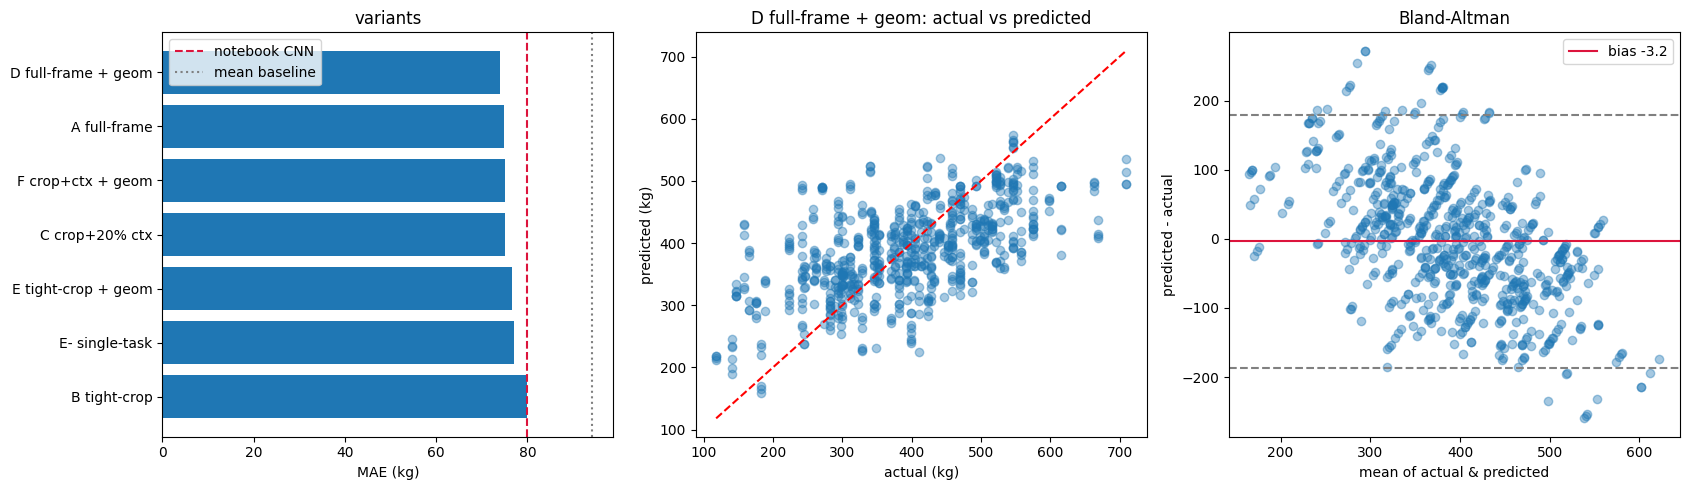

best variant, per-animal           MAE  71.52 | RMSE  89.91 | MAPE 21.36% | R2  0.402 | bias   -5.3 | <=10%  35.5%


{'n': 141,
 'MAE': np.float64(71.5229292944509),
 'RMSE': np.float64(89.91472234620427),
 'MAPE': np.float64(21.363366280559532),
 'R2': np.float64(0.40176692611955456),
 'bias': np.float64(-5.277929065605146),
 'within10': np.float64(35.46099290780142)}

In [71]:
import matplotlib.pyplot as plt

base_rmse = float(np.sqrt(((y_all - y_all.mean())**2).mean()))
print(f"predict-the-mean RMSE ....... {base_rmse:6.2f} kg   <- beat this or the model is useless")
print(f"notebook CNN (image only) ... {92.66:6.2f} kg")
print(f"best variant here ........... {res_df.iloc[0]['RMSE']:6.2f} kg  ({res_df.iloc[0]['variant']})")

try:
    a = res_df.set_index("variant").loc["A full-frame", "MAE"]
    b = res_df.set_index("variant").loc["B tight-crop", "MAE"]
    print(f"\nA full-frame  MAE {a:.2f}   vs   B tight-crop  MAE {b:.2f}")
    print("=> cropping destroys scale; keep the frame or feed geometry back in."
          if a < b else
          "=> cropping helps here, so background clutter was the larger problem.")
except KeyError:
    pass

fig, ax = plt.subplots(1, 3, figsize=(17, 5))
best = res_df.iloc[0]["variant"]
p = oof_store[best]

ax[0].barh(res_df["variant"][::-1], res_df["MAE"][::-1])
ax[0].axvline(79.91, color="crimson", ls="--", label="notebook CNN")
ax[0].axvline(np.abs(y_all - y_all.mean()).mean(), color="gray", ls=":", label="mean baseline")
ax[0].set_xlabel("MAE (kg)"); ax[0].legend(); ax[0].set_title("variants")

ax[1].scatter(y_all, p, alpha=.4)
lim = [y_all.min(), y_all.max()]
ax[1].plot(lim, lim, "r--"); ax[1].set_xlabel("actual (kg)")
ax[1].set_ylabel("predicted (kg)"); ax[1].set_title(f"{best}: actual vs predicted")

d = p - y_all; bias, sd = d.mean(), d.std(ddof=1)
ax[2].scatter((y_all + p) / 2, d, alpha=.4)
ax[2].axhline(bias, color="crimson", label=f"bias {bias:+.1f}")
ax[2].axhline(bias + 1.96*sd, color="gray", ls="--")
ax[2].axhline(bias - 1.96*sd, color="gray", ls="--")
ax[2].set_xlabel("mean of actual & predicted"); ax[2].set_ylabel("predicted - actual")
ax[2].set_title("Bland-Altman"); ax[2].legend()
plt.tight_layout(); plt.show()

# Per-animal averaging - what the app should do with several photos.
pa = pd.DataFrame({"a": dfx["animal_id"], "y": y_all, "p": p}).groupby("a").mean()
report(pa["y"], pa["p"], "best variant, per-animal")

In [72]:
best = res_df[res_df.multitask].iloc[0]["variant"]
feat_cols = GEOM_COLS if res_df.set_index("variant").loc[best, "geom"] else []
crop = res_df.set_index("variant").loc[best, "crop"]

oof_aux = {t: np.full(len(dfx), np.nan) for t in REG_TARGETS}
for k, (tr_i, va_i) in enumerate(splits, 1):
    r = run_fold(dfx.iloc[tr_i], dfx.iloc[va_i], crop_mode=crop,
                 feat_cols=feat_cols, multitask=True, seed=SEED + k)
    for t, v in r.items():
        oof_aux[t][va_i] = v

print(f"auxiliary targets, variant {best}\n")
for t in REG_TARGETS:
    ok = dfx[t].notna().to_numpy() & ~np.isnan(oof_aux[t])
    if ok.sum() < 10:
        continue
    report(dfx[t].to_numpy(float)[ok], oof_aux[t][ok], f"  {t}")

print("\nExpected pattern: ratio_lh learns well (scale-free), "
      "Height and L do not (absolute units).")

      ep   1  val MAE 106.16  best 106.16
      ep  11  val MAE  93.81  best  93.81
      ep  21  val MAE  82.49  best  80.11
      ep  31  val MAE  78.93  best  78.43
      early stop at ep 33
      ep   1  val MAE  91.48  best  91.48
      ep  11  val MAE  81.97  best  81.97
      ep  21  val MAE  73.54  best  73.54
      ep  31  val MAE  72.53  best  72.53
      ep   1  val MAE  85.33  best  85.33
      ep  11  val MAE  78.52  best  78.59
      ep  21  val MAE  75.36  best  75.36
      ep  31  val MAE  73.35  best  73.17
      early stop at ep 40
auxiliary targets, variant D full-frame + geom

  weight                           MAE  74.01 | RMSE  93.43 | MAPE 22.38% | R2  0.347 | bias   -3.1 | <=10%  33.2%
  Height_y                         MAE   8.91 | RMSE  11.74 | MAPE  6.67% | R2  0.357 | bias   +0.7 | <=10%  78.4%
  L_y                              MAE  12.75 | RMSE  16.09 | MAPE  7.70% | R2  0.334 | bias   -0.5 | <=10%  70.6%
  age_years                        MAE   1.28 | RMS

#Block 1 — Setup (rerun blocks 1-5 of the first notebook first)

In [73]:

# Requires from the previous notebook: df, GEOM_COLS, DATA_FULL, report(), SEED
# If this is a fresh runtime, re-run its Blocks 1-5 before continuing.
!pip -q install timm

import os, copy, itertools, warnings
import numpy as np, pandas as pd, torch, torch.nn as nn
import timm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NEEDED = ["df", "GEOM_COLS", "DATA_FULL", "report", "SEED",      # blocks 2-5
          "REG_TARGETS", "CowDataset", "TRAIN_TF", "EVAL_TF",     # block 6 only
          "BATCH_SIZE", "LR", "N_BREEDS", "multitask_loss"]
_missing = [n for n in NEEDED if n not in globals()]
assert not _missing, f"re-run Blocks 1-8 of notebook 1 first; missing: {_missing}"

print(f"images {len(df)} | animals {df['animal_id'].nunique()}")
y_all = df["weight"].to_numpy(float)
groups = df["animal_id"].to_numpy()

# The bar every model here must clear.
print(f"\ntarget: mean {y_all.mean():.1f}  sd {y_all.std():.1f}  "
      f"range {y_all.min():.0f}-{y_all.max():.0f} kg")
report(y_all, np.full_like(y_all, y_all.mean()), "predict-the-mean")
print(f"{'fine-tuned B0 (best so far)':<34} MAE  74.01 | RMSE  93.43 | "
      f"MAPE 22.38% | R2  0.347")

images 728 | animals 141

target: mean 391.6  sd 115.7  range 118-709 kg
predict-the-mean                   MAE  94.13 | RMSE 115.65 | MAPE 29.72% | R2  0.000 | bias   -0.0 | <=10%  24.0%
fine-tuned B0 (best so far)        MAE  74.01 | RMSE  93.43 | MAPE 22.38% | R2  0.347


In [74]:
BACKBONES = {
    "dinov2_s":  "vit_small_patch14_dinov2.lvd142m",
    "clip_b16":  "vit_base_patch16_clip_224.openai",
    "convnext_t": "convnext_tiny.fb_in22k",
    "effv2_s":   "tf_efficientnetv2_s.in21k",
}
FEAT_IMG = 224
CROP_MODES = ["none", "context"]     # the two that won in notebook 1

class PlainDS(Dataset):
    def __init__(self, sub, root, crop_mode, tf, ctx=0.20):
        self.df = sub.reset_index(drop=True)
        self.root, self.crop, self.tf, self.ctx = root, crop_mode, tf, ctx
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r = self.df.loc[i]
        im = Image.open(os.path.join(self.root, r["path"])).convert("RGB")
        if self.crop != "none":
            x1, y1, x2, y2 = r["x1"], r["y1"], r["x2"], r["y2"]
            if self.crop == "context":
                dw, dh = (x2-x1)*self.ctx/2, (y2-y1)*self.ctx/2
                x1, y1, x2, y2 = x1-dw, y1-dh, x2+dw, y2+dh
            W, H = im.size
            box = (max(0,int(x1)), max(0,int(y1)), min(W,int(x2)), min(H,int(y2)))
            if box[2]-box[0] > 8 and box[3]-box[1] > 8:
                im = im.crop(box)
        return self.tf(im)

class Letterbox:
    def __init__(self, size, fill=114): self.size, self.fill = size, fill
    def __call__(self, im):
        w, h = im.size; s = self.size/max(w, h)
        im = im.resize((max(1,round(w*s)), max(1,round(h*s))), Image.BILINEAR)
        c = Image.new("RGB", (self.size,)*2, (self.fill,)*3)
        c.paste(im, ((self.size-im.size[0])//2, (self.size-im.size[1])//2))
        return c

FEAT_TF = transforms.Compose([
    Letterbox(FEAT_IMG), transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

@torch.no_grad()
def extract(model_name, crop_mode):
    m = timm.create_model(model_name, pretrained=True, num_classes=0,
                          **({"dynamic_img_size": True} if "dinov2" in model_name
                             or "clip" in model_name else {}))
    m = m.eval().to(DEVICE)
    dl = DataLoader(PlainDS(df, DATA_FULL, crop_mode, FEAT_TF),
                    batch_size=32, shuffle=False, num_workers=2)
    out = []
    for x in dl:
        # flip-average: the same trick as TTA, applied once at extraction
        x = x.to(DEVICE)
        f = (m(x) + m(torch.flip(x, dims=[3]))) / 2
        out.append(f.float().cpu().numpy())
    del m; torch.cuda.empty_cache()
    return np.concatenate(out)

FEATS = {}
for crop in CROP_MODES:
    for key, name in BACKBONES.items():
        tag = f"{key}|{crop}"
        cache = f"/content/feat_{key}_{crop}.npy"
        if os.path.exists(cache):
            FEATS[tag] = np.load(cache)
        else:
            print("extracting", tag, "...", end=" ", flush=True)
            FEATS[tag] = extract(name, crop)
            np.save(cache, FEATS[tag])
            print(FEATS[tag].shape)

for k, v in FEATS.items():
    print(f"{k:<22} {v.shape}")

extracting dinov2_s|none ... 

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

(728, 384)
extracting clip_b16|none ... 

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  599MB            

...

model.safetensors: downloading bytes:           |  0.00B            

(728, 768)
extracting effv2_s|none ... 

model.safetensors: reconstructing file:   0%|          |  0.00B /  193MB            

model.safetensors: downloading bytes:           |  0.00B            

(728, 1280)
extracting dinov2_s|context ... (728, 384)
extracting clip_b16|context ... (728, 768)
extracting convnext_t|context ... (728, 768)
extracting effv2_s|context ... (728, 1280)
dinov2_s|none          (728, 384)
clip_b16|none          (728, 768)
convnext_t|none        (728, 768)
effv2_s|none           (728, 1280)
dinov2_s|context       (728, 384)
clip_b16|context       (728, 768)
convnext_t|context     (728, 768)
effv2_s|context        (728, 1280)


In [75]:
GEOM = df[GEOM_COLS].to_numpy(float)
GEOM = (GEOM - GEOM.mean(0)) / (GEOM.std(0) + 1e-8)

HEADS = {
    "ridge":  lambda: make_pipeline(StandardScaler(),
                                    RidgeCV(alphas=np.logspace(-2, 5, 40))),
    "pca64+ridge": lambda: make_pipeline(StandardScaler(), PCA(64, random_state=SEED),
                                         RidgeCV(alphas=np.logspace(-2, 5, 40))),
    "rf":     lambda: RandomForestRegressor(600, min_samples_leaf=2,
                                            max_features=0.3, n_jobs=-1,
                                            random_state=SEED),
    "pca64+rf": lambda: make_pipeline(StandardScaler(), PCA(64, random_state=SEED),
                                      RandomForestRegressor(600, min_samples_leaf=2,
                                                            n_jobs=-1, random_state=SEED)),
    "hgb":    lambda: HistGradientBoostingRegressor(max_depth=3, max_iter=400,
                                                    learning_rate=0.05,
                                                    random_state=SEED),
    "svr":    lambda: make_pipeline(StandardScaler(), SVR(C=100, epsilon=5)),
}

gkf = GroupKFold(n_splits=5)
SPLITS = list(gkf.split(df, groups=groups))

def oof_predict(X, make_head):
    p = np.zeros(len(X))
    for tr, va in SPLITS:
        h = make_head().fit(X[tr], y_all[tr])
        p[va] = h.predict(X[va])
    return p

rows = []
for tag, F in FEATS.items():
    for use_geom in (False, True):
        X = np.hstack([F, GEOM]) if use_geom else F
        for hname, make in HEADS.items():
            p = oof_predict(X, make)
            m = report(y_all, p, f"{tag}{'+geom' if use_geom else '':<6} {hname}")
            rows.append(dict(features=tag, geom=use_geom, head=hname,
                             **{k: m[k] for k in ("MAE","RMSE","MAPE","R2","bias","within10")}))

frozen = pd.DataFrame(rows).sort_values("MAE").reset_index(drop=True)
print("\n" + "="*78)
display(frozen.head(15).round(2))

dinov2_s|none       ridge          MAE  94.48 | RMSE 115.28 | MAPE 28.26% | R2  0.006 | bias   +2.2 | <=10%  25.5%
dinov2_s|none       pca64+ridge    MAE  84.55 | RMSE 103.24 | MAPE 25.20% | R2  0.203 | bias   +4.7 | <=10%  26.2%
dinov2_s|none       rf             MAE  84.60 | RMSE 102.58 | MAPE 26.28% | R2  0.213 | bias   +3.7 | <=10%  26.0%
dinov2_s|none       pca64+rf       MAE  88.27 | RMSE 107.33 | MAPE 27.40% | R2  0.139 | bias   +5.2 | <=10%  25.0%
dinov2_s|none       hgb            MAE  83.91 | RMSE 102.56 | MAPE 25.74% | R2  0.214 | bias   +5.8 | <=10%  26.0%
dinov2_s|none       svr            MAE  81.97 | RMSE  99.17 | MAPE 25.19% | R2  0.265 | bias   +2.2 | <=10%  26.1%
dinov2_s|none+geom  ridge          MAE  93.71 | RMSE 114.64 | MAPE 27.88% | R2  0.017 | bias   +1.3 | <=10%  25.7%
dinov2_s|none+geom  pca64+ridge    MAE  85.27 | RMSE 104.35 | MAPE 25.51% | R2  0.186 | bias   +4.7 | <=10%  25.7%
dinov2_s|none+geom  rf             MAE  84.58 | RMSE 102.61 | MAPE 26.29% | R2  

,features,geom,head,MAE,RMSE,MAPE,R2,bias,within10
0,convnext_t|none,True,svr,78.55,97.09,24.46,0.30,2.19,27.88
1,convnext_t|none,False,svr,78.86,97.44,24.55,0.29,2.17,27.75
2,convnext_t|context,True,svr,79.02,97.07,24.44,0.30,1.96,27.06
3,convnext_t|context,False,svr,79.28,97.37,24.50,0.29,1.87,27.06
4,dinov2_s|context,True,svr,79.57,96.94,24.45,0.30,2.03,28.16
5,dinov2_s|context,True,hgb,80.08,99.12,24.59,0.27,5.40,28.57
6,dinov2_s|context,False,svr,80.17,97.47,24.65,0.29,2.24,28.43
7,dinov2_s|context,False,hgb,80.48,99.30,24.76,0.26,5.25,29.26
8,convnext_t|context,True,pca64+ridge,81.17,100.11,24.18,0.25,2.66,27.75
9,dinov2_s|none,True,svr,81.20,98.46,24.93,0.28,1.93,26.65


using convnext_t|none+geom / svr

   15% of train animals (~ 16) -> MAE  96.22 +/- 9.84
   30% of train animals (~ 33) -> MAE  85.32 +/- 8.78
   45% of train animals (~ 50) -> MAE  83.52 +/- 9.13
   60% of train animals (~ 67) -> MAE  84.47 +/- 4.41
   75% of train animals (~ 84) -> MAE  82.03 +/- 7.78
   90% of train animals (~101) -> MAE  80.48 +/- 4.51
  100% of train animals (~112) -> MAE  78.56 +/- 4.04


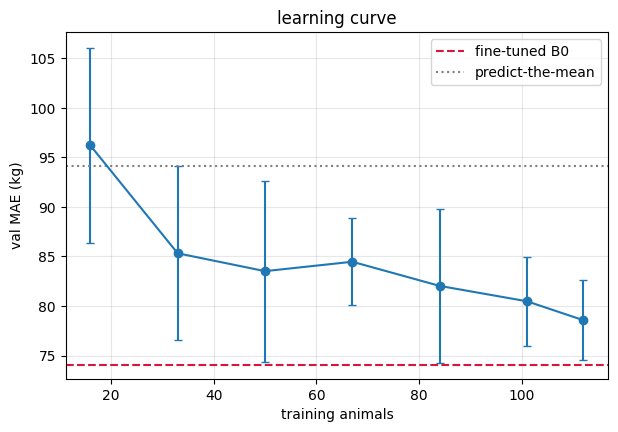


slope over the last third: 12.39 kg per 100 extra animals
=> more data still pays


In [76]:
best = frozen.iloc[0]
Xb = np.hstack([FEATS[best["features"]], GEOM]) if best["geom"] else FEATS[best["features"]]
make_best = HEADS[best["head"]]
print(f"using {best['features']}{'+geom' if best['geom'] else ''} / {best['head']}\n")

rng = np.random.default_rng(SEED)
uniq = df["animal_id"].unique()
fractions = [0.15, 0.3, 0.45, 0.6, 0.75, 0.9, 1.0]
curve = []

for frac in fractions:
    maes = []
    for tr, va in SPLITS:
        tr_animals = pd.unique(groups[tr])
        keep = rng.choice(tr_animals, max(4, int(len(tr_animals)*frac)), replace=False)
        sub = tr[np.isin(groups[tr], keep)]
        h = make_best().fit(Xb[sub], y_all[sub])
        maes.append(np.abs(h.predict(Xb[va]) - y_all[va]).mean())
    curve.append(dict(frac=frac, n_animals=int(len(uniq)*0.8*frac),
                      MAE=np.mean(maes), sd=np.std(maes)))
    print(f"  {frac:>4.0%} of train animals (~{curve[-1]['n_animals']:>3}) -> "
          f"MAE {curve[-1]['MAE']:6.2f} +/- {curve[-1]['sd']:.2f}")

curve = pd.DataFrame(curve)
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4.5))
plt.errorbar(curve.n_animals, curve.MAE, yerr=curve.sd, marker="o", capsize=3)
plt.axhline(74.01, color="crimson", ls="--", label="fine-tuned B0")
plt.axhline(np.abs(y_all - y_all.mean()).mean(), color="gray", ls=":", label="predict-the-mean")
plt.xlabel("training animals"); plt.ylabel("val MAE (kg)")
plt.title("learning curve"); plt.legend(); plt.grid(alpha=.3); plt.show()

tail = curve.MAE.iloc[-3:].to_numpy()
slope = (tail[0] - tail[-1]) / max(1, curve.n_animals.iloc[-1] - curve.n_animals.iloc[-3])
print(f"\nslope over the last third: {slope*100:.2f} kg per 100 extra animals")
print("=> more data still pays" if slope*100 > 2 else
      "=> curve has flattened: the limit is the INPUT (scale), not the sample size")

In [18]:
import torch.nn.functional as F

EPOCHS_LONG, PATIENCE_LONG = 150, 30

def run_fold_v2(tr, va, *, crop_mode, feat_cols, multitask=True,
                backbone="efficientnet_b0", root=DATA_FULL,
                epochs=EPOCHS_LONG, seed=SEED, log_every=15):
    torch.manual_seed(seed)
    def _stats(t):
        mu, sd = tr[t].mean(), tr[t].std()
        mu = 0.0 if pd.isna(mu) else float(mu)
        sd = float(sd) if (not pd.isna(sd) and sd > 1e-6) else 1.0
        return mu, sd
    norm = {t: _stats(t) for t in REG_TARGETS}

    mk = lambda s, tf: CowDataset(s, root, tf, crop_mode=crop_mode,
                                  feat_cols=feat_cols, norm=norm)
    dl_tr = DataLoader(mk(tr, TRAIN_TF), batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=2, drop_last=True)
    dl_tr_eval = DataLoader(mk(tr, EVAL_TF), batch_size=BATCH_SIZE, num_workers=2)
    dl_va = DataLoader(mk(va, EVAL_TF), batch_size=BATCH_SIZE, num_workers=2)

    model = MultiTaskNetV2(backbone, len(feat_cols), N_BREEDS,
                           len(REG_TARGETS), multitask=multitask).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    wmu, wsd = norm["weight"]

    def mae_on(dl):
        model.eval(); P, T = [], []
        with torch.no_grad():
            for x, f, yv, m, b in dl:
                ro, _ = model(x.to(DEVICE), f.to(DEVICE))
                P.append(ro[:, 0].cpu().numpy()); T.append(yv[:, 0].numpy())
        return float(np.abs((np.concatenate(P) - np.concatenate(T)) * wsd).mean())

    best, best_wts, stale, hist = 1e9, copy.deepcopy(model.state_dict()), 0, []
    for ep in range(epochs):
        model.train()
        for x, f, yv, m, b in dl_tr:
            x, f, yv, m, b = [t.to(DEVICE) for t in (x, f, yv, m, b)]
            opt.zero_grad()
            ro, bo = model(x, f)
            loss, _ = multitask_loss(ro, bo, yv, m, b, model.log_var, multitask)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sch.step()

        v = mae_on(dl_va)
        if v < best - 0.1:
            best, best_wts, stale = v, copy.deepcopy(model.state_dict()), 0
        else:
            stale += 1
        if ep % log_every == 0 or stale >= PATIENCE_LONG:
            t_ = mae_on(dl_tr_eval)          # the diagnostic that was missing
            hist.append((ep, t_, v))
            print(f"      ep {ep+1:>3}  train {t_:6.2f}  val {v:6.2f}  "
                  f"gap {v-t_:+6.2f}  best {best:6.2f}")
        if stale >= PATIENCE_LONG:
            print(f"      early stop at ep {ep+1}")
            break

    model.load_state_dict(best_wts)
    model.eval(); out = []
    with torch.no_grad():
        for x, f, yv, m, b in dl_va:
            x, f = x.to(DEVICE), f.to(DEVICE)
            r1, _ = model(x, f); r2, _ = model(torch.flip(x, dims=[3]), f)
            out.append(((r1 + r2) / 2).cpu().numpy())
    ps = np.concatenate(out)
    return {t: ps[:, i] * norm[t][1] + norm[t][0]
            for i, t in enumerate(REG_TARGETS[:ps.shape[1]])}, hist, best_wts


class MultiTaskNetV2(nn.Module):
    # Same as notebook 1 but the backbone is swappable via timm.
    def __init__(self, backbone, n_feats=0, n_breeds=2, n_reg=5,
                 dropout=0.4, multitask=True):
        super().__init__()
        self.backbone = timm.create_model(backbone, pretrained=True, num_classes=0)
        d_img = self.backbone.num_features
        self.tab = nn.Sequential(
            nn.BatchNorm1d(n_feats), nn.Linear(n_feats, 64), nn.SiLU(),
            nn.Dropout(dropout/2), nn.Linear(64, 64), nn.SiLU(),
        ) if n_feats else None
        d = d_img + (64 if n_feats else 0)
        self.trunk = nn.Sequential(nn.Dropout(dropout), nn.Linear(d, 256), nn.SiLU())
        self.reg = nn.Linear(256, n_reg if multitask else 1)
        self.breed = nn.Linear(256, n_breeds) if multitask else None
        nn.init.zeros_(self.reg.weight); nn.init.zeros_(self.reg.bias)
        self.log_var = nn.Parameter(torch.zeros((n_reg if multitask else 1) + 1))

    def forward(self, img, feats):
        z = self.backbone(img)
        if self.tab is not None:
            z = torch.cat([z, self.tab(feats)], 1)
        z = self.trunk(z)
        return self.reg(z), (self.breed(z) if self.breed is not None else None)


# Winner from notebook 1 (D: full frame + geometry), now with a real budget.
dfx = df.copy()
dfx[GEOM_COLS] = (dfx[GEOM_COLS] - dfx[GEOM_COLS].mean()) / (dfx[GEOM_COLS].std() + 1e-8)

oof = np.full(len(dfx), np.nan)
for k, (tr_i, va_i) in enumerate(SPLITS[:3], 1):
    print(f"   fold {k}  train {len(tr_i)} / val {len(va_i)}")
    r, hist, best_wts = run_fold_v2(dfx.iloc[tr_i], dfx.iloc[va_i],
                          crop_mode="none", feat_cols=GEOM_COLS, seed=SEED+k)
    oof[va_i] = r["weight"]

    save_path = f"{DRIVE}/best_model_fold{k}.pth"
    torch.save(best_wts, save_path)
    print(f"   saved weights to {save_path}")

ok = ~np.isnan(oof)
report(y_all[ok], oof[ok], "B0, 150 epochs, full+geom")
print(f"{'same config, 40 epochs':<34} MAE  74.01 | RMSE  93.43 | R2  0.347")

NameError: name 'SPLITS' is not defined

# Final training run — long budget, best configuration, saved model
What the previous three rounds settled
Round 1 — cropping. Full frame beat a tight crop by 5 kg (74.87 vs 79.86); adding bounding-box geometry recovered most of the loss on cropped inputs (79.86 → 76.60). Best overall: full frame + geometry, MAE 74.01, R² 0.347.

Round 2 — frozen features. Best frozen configuration was convnext_tiny (full frame) + geometry + SVR at MAE 78.55, R² 0.30 — 4.5 kg worse than fine-tuning. Three further findings:

SVR dominates, random forest never reached the top 15. On 700-dimensional embeddings with ~700 samples, a margin-based regressor generalises where tree ensembles do not.
Geometry added only 0.31 kg on full-frame features (78.86 → 78.55), versus 3.3 kg on tight crops. A full frame already encodes scale; the explicit numbers are mostly redundant once you stop cropping.
Full frame beat context-crop again, and convnext_tiny beat dinov2_s.
So: fine-tuning wins, the frozen path is closed.

Round 3 — auxiliary targets. Weight, Height and L all landed at R² ≈ 0.34 — the model has learned a single "how big is this animal" factor, not three separate skills. And the arithmetic closes exactly:

W∝H2L⇒σW≈2σH+σL=2(6.67%)+7.70%=21.0%vs measured 22.38%

Weight error is the linear-dimension error, tripled by the cube law. To reach 8% on weight you need 2.7% on linear dimensions — currently 7%.

Round 4 — learning curve. 16 → 112 animals moved MAE 96.2 → 78.6. Fitting a·n^-b + c gives an exponent of only 0.127 (typical deep-learning curves sit at 0.3–0.5), and the asymptote is not identifiable from seven noisy points (±253 kg — ignore any specific value). What is robust is the short extrapolation: doubling the herd to ~224 animals buys about 4.6 kg, and reaching 500 animals buys about 9.5 kg. Real, but slow, and nowhere near the target on its own.

What this notebook does
block	purpose	time
2	learning-curve fit, reproducible	seconds
3	diagnostic: train MAE vs val MAE at full budget — settles underfit vs overfit	~20 min
4	configuration screen: backbone × augmentation × feature set	~60 min
5	final 5-fold run, saves every fold to Drive	2–3 h
6	final metrics, plots, out-of-fold predictions	minutes
7	inference helper for ai-api	—
In a hurry: run blocks 1, 3, then 5 with the defaults already set from rounds 1–3, and skip the screen.

In [29]:
# Needs Blocks 1-8 of Multitask_Weight_Experiment.ipynb to have run.
!pip -q install timm

import os, copy, json, math, warnings
from pathlib import Path
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
import timm, matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.model_selection import GroupKFold

warnings.filterwarnings("ignore")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NEEDED = ["df", "GEOM_COLS", "DATA_FULL", "report", "SEED", "REG_TARGETS",
          "CowDataset", "N_BREEDS", "multitask_loss", "LetterboxPad", "NORM"]
_missing = [n for n in NEEDED if n not in globals()]
assert not _missing, f"re-run Blocks 1-8 of notebook 1 first; missing: {_missing}"

SAVE_DIR = "/content/drive/MyDrive/KSU/Research/SmartWeight/weight_model"
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE   = 320
BATCH_SIZE = 16
LR         = 3e-4
y_all  = df["weight"].to_numpy(float)
groups = df["animal_id"].to_numpy()
SPLITS = list(GroupKFold(n_splits=5).split(df, groups=groups))

print(f"device {DEVICE} | images {len(df)} | animals {df['animal_id'].nunique()}")
print(f"saving to {SAVE_DIR}")
report(y_all, np.full_like(y_all, y_all.mean()), "predict-the-mean")
print(f"{'round 1 best (B0, 40 ep)':<34} MAE  74.01 | RMSE  93.43 | R2  0.347")
print(f"{'round 2 best (frozen convnext)':<34} MAE  78.55 | RMSE  97.09 | R2  0.300")

device cuda | images 728 | animals 141
saving to /content/drive/MyDrive/KSU/Research/SmartWeight/weight_model
predict-the-mean                   MAE  94.13 | RMSE 115.65 | MAPE 29.72% | R2  0.000 | bias   -0.0 | <=10%  24.0%
round 1 best (B0, 40 ep)           MAE  74.01 | RMSE  93.43 | R2  0.347
round 2 best (frozen convnext)     MAE  78.55 | RMSE  97.09 | R2  0.300


MAE(n) = 100.1*n^-0.127 + 24.5
exponent 0.127  (deep-learning curves usually 0.3-0.5 -> this is shallow)
asymptote 24.5 +/- 253 kg  -> NOT identifiable, do not quote it

  n= 112 -> MAE  79.38 kg
  n= 224 -> MAE  74.74 kg
  n= 300 -> MAE  72.90 kg
  n= 500 -> MAE  69.85 kg

doubling the herd buys 4.6 kg


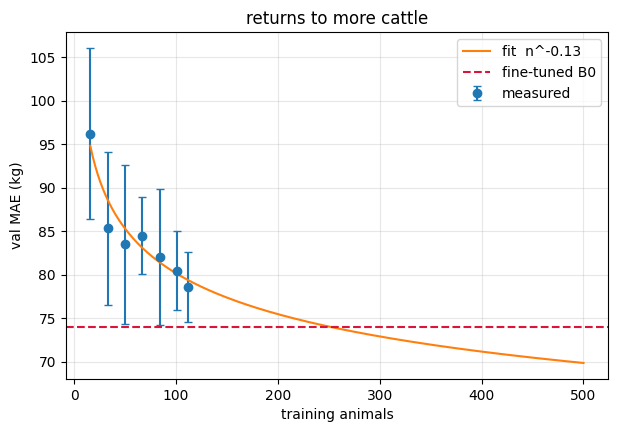

In [81]:
from scipy.optimize import curve_fit

n   = np.array([16, 33, 50, 67, 84, 101, 112], float)
mae = np.array([96.22, 85.32, 83.52, 84.47, 82.03, 80.48, 78.56])
sd  = np.array([9.84, 8.78, 9.13, 4.41, 7.78, 4.51, 4.04])

f = lambda x, a, b, c: a * x**(-b) + c
p, cov = curve_fit(f, n, mae, p0=[200, .5, 60], sigma=sd, maxfev=200000,
                   bounds=([0, .01, 0], [1e6, 3, 95]))
err = np.sqrt(np.diag(cov))
print(f"MAE(n) = {p[0]:.1f}*n^-{p[1]:.3f} + {p[2]:.1f}")
print(f"exponent {p[1]:.3f}  (deep-learning curves usually 0.3-0.5 -> this is shallow)")
print(f"asymptote {p[2]:.1f} +/- {err[2]:.0f} kg  -> NOT identifiable, do not quote it\n")
for N in (112, 224, 300, 500):
    print(f"  n={N:>4} -> MAE {f(N, *p):6.2f} kg")
print(f"\ndoubling the herd buys {f(112,*p)-f(224,*p):.1f} kg")

plt.figure(figsize=(7, 4.5))
plt.errorbar(n, mae, yerr=sd, fmt="o", capsize=3, label="measured")
xs = np.linspace(16, 500, 200)
plt.plot(xs, f(xs, *p), label=f"fit  n^-{p[1]:.2f}")
plt.axhline(74.01, color="crimson", ls="--", label="fine-tuned B0")
plt.xlabel("training animals"); plt.ylabel("val MAE (kg)")
plt.legend(); plt.grid(alpha=.3); plt.title("returns to more cattle"); plt.show()

In [33]:
IMG_SIZE = 336

def build_tf(strength: str, img_size=IMG_SIZE):
    lb = LetterboxPad(img_size)
    if strength == "light":
        aug = [transforms.RandomHorizontalFlip(0.5),
               transforms.RandomAffine(degrees=4, translate=(0.03, 0.03),
                                       scale=(0.97, 1.03)),
               transforms.ColorJitter(0.15, 0.15, 0.1, 0.02)]
    elif strength == "medium":
        aug = [transforms.RandomHorizontalFlip(0.5),
               transforms.RandomAffine(degrees=7, translate=(0.05, 0.05),
                                       scale=(0.95, 1.05)),
               transforms.ColorJitter(0.25, 0.25, 0.2, 0.03)]
    elif strength == "strong":
        # scale jitter widened deliberately: it is the one augmentation that
        # simulates a different shooting distance
        aug = [transforms.RandomHorizontalFlip(0.5),
               transforms.RandomAffine(degrees=10, translate=(0.08, 0.08),
                                       scale=(0.85, 1.15)),
               transforms.ColorJitter(0.35, 0.35, 0.3, 0.05),
               transforms.RandomGrayscale(p=0.05)]
    else:
        raise ValueError(strength)
    return transforms.Compose([lb, *aug, transforms.ToTensor(), NORM])

EVAL_TF_F = transforms.Compose([LetterboxPad(IMG_SIZE), transforms.ToTensor(), NORM])
print("augmentation levels: light / medium / strong   (RandomErasing removed)")

augmentation levels: light / medium / strong   (RandomErasing removed)


In [31]:
class WeightNet(nn.Module):
    def __init__(self, backbone, n_feats=0, n_breeds=2, n_reg=5,
                 dropout=0.4, multitask=True):
        super().__init__()
        self.backbone = timm.create_model(
            backbone, pretrained=True, num_classes=0,
            **({"dynamic_img_size": True} if "dinov2" in backbone or "clip" in backbone else {})
        )
        d_img = self.backbone.num_features
        self.tab = nn.Sequential(
            nn.BatchNorm1d(n_feats), nn.Linear(n_feats, 64), nn.SiLU(),
            nn.Dropout(dropout / 2), nn.Linear(64, 64), nn.SiLU(),
        ) if n_feats else None
        d = d_img + (64 if n_feats else 0)
        self.trunk = nn.Sequential(nn.Dropout(dropout), nn.Linear(d, 256), nn.SiLU())
        self.reg = nn.Linear(256, n_reg if multitask else 1)
        self.breed = nn.Linear(256, n_breeds) if multitask else None
        nn.init.zeros_(self.reg.weight); nn.init.zeros_(self.reg.bias)
        self.log_var = nn.Parameter(torch.zeros((n_reg if multitask else 1) + 1))

    def forward(self, img, feats):
        z = self.backbone(img)
        if self.tab is not None:
            z = torch.cat([z, self.tab(feats)], 1)
        z = self.trunk(z)
        return self.reg(z), (self.breed(z) if self.breed is not None else None)


def train_one(tr, va, *, backbone="efficientnet_b0", aug="medium",
              feat_cols=(), crop_mode="none", epochs=150, patience=30,
              multitask=True, seed=SEED, log_every=15, use_ema=True, verbose=True):
    torch.manual_seed(seed)
    feat_cols = list(feat_cols)

    def _stats(t):
        mu, sd_ = tr[t].mean(), tr[t].std()
        mu = 0.0 if pd.isna(mu) else float(mu)
        sd_ = float(sd_) if (not pd.isna(sd_) and sd_ > 1e-6) else 1.0
        return mu, sd_
    norm = {t: _stats(t) for t in REG_TARGETS}
    wmu, wsd = norm["weight"]

    mk = lambda s, tf: CowDataset(s, DATA_FULL, tf, crop_mode=crop_mode,
                                  feat_cols=feat_cols, norm=norm)
    dl_tr      = DataLoader(mk(tr, build_tf(aug)), batch_size=BATCH_SIZE,
                            shuffle=True, num_workers=2, drop_last=True)
    dl_tr_eval = DataLoader(mk(tr, EVAL_TF_F), batch_size=BATCH_SIZE, num_workers=2)
    dl_va      = DataLoader(mk(va, EVAL_TF_F), batch_size=BATCH_SIZE, num_workers=2)

    model = WeightNet(backbone, len(feat_cols), N_BREEDS, len(REG_TARGETS),
                      multitask=multitask).to(DEVICE)
    ema = torch.optim.swa_utils.AveragedModel(
        model, avg_fn=lambda a, c, _: 0.999 * a + 0.001 * c,
        use_buffers=True,      # without this the EMA keeps BatchNorm stats from init
    ) if use_ema else None
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    def mae_of(net, dl):
        net.eval(); P, T = [], []
        with torch.no_grad():
            for x, f_, yv, m, b in dl:
                ro, _ = net(x.to(DEVICE), f_.to(DEVICE))
                P.append(ro[:, 0].cpu().numpy()); T.append(yv[:, 0].numpy())
        return float(np.abs((np.concatenate(P) - np.concatenate(T)) * wsd).mean())

    best, best_wts, stale, hist = 1e9, copy.deepcopy(model.state_dict()), 0, []
    for ep in range(epochs):
        model.train()
        for x, f_, yv, m, b in dl_tr:
            x, f_, yv, m, b = [t.to(DEVICE) for t in (x, f_, yv, m, b)]
            opt.zero_grad()
            ro, bo = model(x, f_)
            loss, _ = multitask_loss(ro, bo, yv, m, b, model.log_var, multitask)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            if ema is not None:
                ema.update_parameters(model)
        sch.step()

        v = mae_of(model, dl_va)
        if v < best - 0.1:
            best, best_wts, stale = v, copy.deepcopy(model.state_dict()), 0
        else:
            stale += 1
        if verbose and (ep % log_every == 0 or stale >= patience or ep == epochs - 1):
            t_ = mae_of(model, dl_tr_eval)
            hist.append(dict(epoch=ep + 1, train=t_, val=v))
            print(f"      ep {ep+1:>3}  train {t_:6.2f}  val {v:6.2f}  "
                  f"gap {v-t_:+6.2f}  best {best:6.2f}")
        if stale >= patience:
            print(f"      early stop at ep {ep+1}")
            break

    model.load_state_dict(best_wts)
    if ema is not None:
        v_ema = mae_of(ema.module, dl_va)
        if v_ema < best:
            print(f"      EMA better: {v_ema:.2f} < {best:.2f}, using EMA weights")
            model.load_state_dict(ema.module.state_dict()); best = v_ema

    model.eval(); out = []
    with torch.no_grad():
        for x, f_, yv, m, b in dl_va:                      # flip TTA
            x, f_ = x.to(DEVICE), f_.to(DEVICE)
            r1, _ = model(x, f_); r2, _ = model(torch.flip(x, dims=[3]), f_)
            out.append(((r1 + r2) / 2).cpu().numpy())
    ps = np.concatenate(out)
    preds = {t: ps[:, i] * norm[t][1] + norm[t][0]
             for i, t in enumerate(REG_TARGETS[:ps.shape[1]])}
    return dict(model=model, preds=preds, norm=norm, best=best,
                hist=pd.DataFrame(hist), feat_cols=feat_cols)


diagnostic: efficientnet_b0, medium aug, full frame + geometry, 150 epochs
      ep   1  train  82.19  val  89.01  gap  +6.82  best  89.01
      ep  11  train  23.22  val  82.54  gap +59.32  best  73.58
      ep  21  train  19.22  val  77.21  gap +57.99  best  73.58
      ep  31  train  21.15  val  75.89  gap +54.74  best  73.58
      ep  32  train  14.70  val  77.17  gap +62.46  best  73.58
      early stop at ep 32


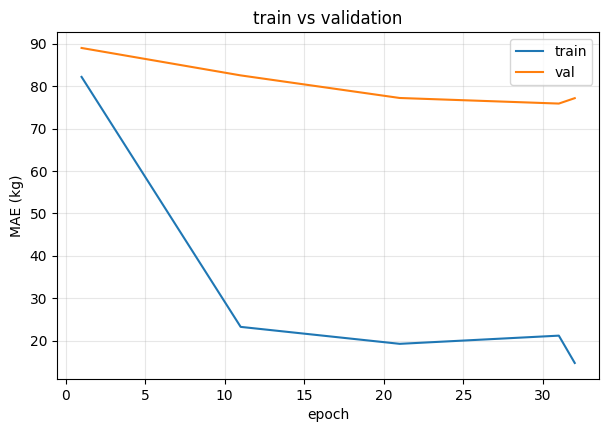


final gap +62.5 kg | best val 73.58 (round 1, 40 epochs: 78.4 on this fold)
=> OVERFITTED: regularise harder, stronger augmentation


In [84]:
# Standardise geometry once, as in the earlier rounds.
dfx = df.copy()
dfx[GEOM_COLS] = (dfx[GEOM_COLS] - dfx[GEOM_COLS].mean()) / (dfx[GEOM_COLS].std() + 1e-8)

tr_i, va_i = SPLITS[0]
print("diagnostic: efficientnet_b0, medium aug, full frame + geometry, 150 epochs")
diag = train_one(dfx.iloc[tr_i], dfx.iloc[va_i],
                 backbone="efficientnet_b0", aug="medium",
                 feat_cols=GEOM_COLS, crop_mode="none", epochs=150, log_every=10)

h = diag["hist"]
plt.figure(figsize=(7, 4.5))
plt.plot(h.epoch, h.train, label="train"); plt.plot(h.epoch, h.val, label="val")
plt.xlabel("epoch"); plt.ylabel("MAE (kg)"); plt.legend(); plt.grid(alpha=.3)
plt.title("train vs validation"); plt.show()

gap = h.val.iloc[-1] - h.train.iloc[-1]
print(f"\nfinal gap {gap:+.1f} kg | best val {diag['best']:.2f} "
      f"(round 1, 40 epochs: 78.4 on this fold)")
print("=> UNDERFITTED: go bigger, lighter augmentation" if gap < 15 else
      "=> OVERFITTED: regularise harder, stronger augmentation" if gap > 25 else
      "=> balanced: gains now come from data or inputs, not capacity")

In [85]:
BREED_COLS = [c for c in dfx.columns if c.startswith("breed_")
              and pd.api.types.is_numeric_dtype(dfx[c])]
FEATURE_SETS = {
    "geom":        GEOM_COLS,
    "geom+breed":  GEOM_COLS + BREED_COLS,
    "none":        [],
}
print("breed columns available as input:", BREED_COLS)

CONFIGS = [
    dict(backbone="efficientnet_b0",    aug="medium", feats="geom"),
    dict(backbone="efficientnet_b0",    aug="light",  feats="geom"),
    dict(backbone="convnext_tiny",      aug="medium", feats="geom"),
    dict(backbone="tf_efficientnetv2_s", aug="medium", feats="geom"),
    dict(backbone="efficientnet_b0",    aug="medium", feats="geom+breed"),
]

screen = []
for cfg in CONFIGS:
    tag = f"{cfg['backbone']}/{cfg['aug']}/{cfg['feats']}"
    print(f"\n--- {tag} ---")
    r = train_one(dfx.iloc[tr_i], dfx.iloc[va_i],
                  backbone=cfg["backbone"], aug=cfg["aug"],
                  feat_cols=FEATURE_SETS[cfg["feats"]], crop_mode="none",
                  epochs=150, log_every=30)
    screen.append(dict(config=tag, val_MAE=r["best"],
                       gap=float(r["hist"].val.iloc[-1] - r["hist"].train.iloc[-1]),
                       **cfg))
    del r; torch.cuda.empty_cache()

screen_df = pd.DataFrame(screen).sort_values("val_MAE").reset_index(drop=True)
display(screen_df.round(2))
BEST = screen_df.iloc[0]
print(f"\nwinner: {BEST['config']}  (single fold - treat close scores as a tie)")

breed columns available as input: ['breed_id']

--- efficientnet_b0/medium/geom ---
      ep   1  train  82.19  val  89.00  gap  +6.81  best  89.00
      ep  31  train  19.43  val  75.51  gap +56.09  best  73.39
      ep  57  train   9.33  val  78.35  gap +69.02  best  73.39
      early stop at ep 57

--- efficientnet_b0/light/geom ---
      ep   1  train  82.03  val  90.51  gap  +8.47  best  90.51
      ep  31  train  17.44  val  78.48  gap +61.04  best  74.67
      ep  43  train  11.26  val  78.59  gap +67.33  best  74.67
      early stop at ep 43

--- convnext_tiny/medium/geom ---


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

      ep   1  train  96.54  val  84.48  gap -12.05  best  84.48
      ep  31  train  82.01  val  91.40  gap  +9.39  best  78.91
      ep  49  train  68.60  val  93.53  gap +24.93  best  78.91
      early stop at ep 49

--- tf_efficientnetv2_s/medium/geom ---


model.safetensors: reconstructing file:   0%|          |  0.00B / 86.5MB            

model.safetensors: downloading bytes:           |  0.00B            

      ep   1  train  79.13  val  82.62  gap  +3.49  best  82.62
      ep  31  train  11.39  val  89.50  gap +78.11  best  72.67
      ep  45  train   9.74  val  85.19  gap +75.45  best  72.67
      early stop at ep 45

--- efficientnet_b0/medium/geom+breed ---
      ep   1  train  85.18  val  91.42  gap  +6.24  best  91.42
      ep  31  train  14.97  val  82.83  gap +67.86  best  69.82
      ep  53  train   9.24  val  79.48  gap +70.24  best  69.82
      early stop at ep 53


,config,val_MAE,gap,backbone,aug,feats
0,efficientnet_b0/medium/geom+breed,69.82,70.24,efficientnet_b0,medium,geom+breed
1,tf_efficientnetv2_s/medium/geom,72.67,75.45,tf_efficientnetv2_s,medium,geom
2,efficientnet_b0/medium/geom,73.39,69.02,efficientnet_b0,medium,geom
3,efficientnet_b0/light/geom,74.67,67.33,efficientnet_b0,light,geom
4,convnext_tiny/medium/geom,78.91,24.93,convnext_tiny,medium,geom



winner: efficientnet_b0/medium/geom+breed  (single fold - treat close scores as a tie)


In [86]:
FINAL = dict(
    backbone = BEST["backbone"] if "BEST" in globals() else "efficientnet_b0",
    aug      = BEST["aug"]      if "BEST" in globals() else "medium",
    feats    = BEST["feats"]    if "BEST" in globals() else "geom",
    crop_mode = "none",
    epochs    = 200,
    patience  = 40,
)
feat_cols = FEATURE_SETS[FINAL["feats"]]
print("final configuration:", FINAL)

# The exact statistics used to standardise the tabular features, so inference
# can reproduce them. Recomputing from a different dataframe would not match.
geom_stats = {c: (float(df[c].mean()), float(df[c].std() + 1e-8)) for c in feat_cols}

oof = np.full(len(dfx), np.nan)
manifest = dict(created=pd.Timestamp.utcnow().isoformat(), img_size=IMG_SIZE,
                reg_targets=REG_TARGETS, n_breeds=int(N_BREEDS),
                feat_cols=feat_cols, geom_stats=geom_stats, folds=[], **FINAL)

for k, (tr_i_, va_i_) in enumerate(SPLITS, 1):
    print(f"\n=== fold {k}/5  train {len(tr_i_)} / val {len(va_i_)} "
          f"({dfx.iloc[va_i_]['animal_id'].nunique()} animals) ===")
    r = train_one(dfx.iloc[tr_i_], dfx.iloc[va_i_],
                  backbone=FINAL["backbone"], aug=FINAL["aug"],
                  feat_cols=feat_cols, crop_mode=FINAL["crop_mode"],
                  epochs=FINAL["epochs"], patience=FINAL["patience"],
                  seed=SEED + k, log_every=25)
    oof[va_i_] = r["preds"]["weight"]

    path = f"{SAVE_DIR}/fold{k}.pth"
    torch.save(dict(state_dict=r["model"].state_dict(), norm=r["norm"],
                    val_mae=r["best"], fold=k), path)
    manifest["folds"].append(dict(fold=k, path=os.path.basename(path),
                                  val_mae=float(r["best"]),
                                  n_val_animals=int(dfx.iloc[va_i_]["animal_id"].nunique())))
    print(f"  saved {path}  (val MAE {r['best']:.2f})")
    del r; torch.cuda.empty_cache()

report(y_all, oof, "FINAL out-of-fold")
manifest["oof"] = {k: float(v) for k, v in report(y_all, oof).items()}

with open(f"{SAVE_DIR}/manifest.json", "w", encoding="utf-8") as fh:
    json.dump(manifest, fh, ensure_ascii=False, indent=2)
pd.DataFrame({"animal_id": dfx["animal_id"], "path": dfx["path"],
              "actual": y_all, "predicted": oof}).to_csv(
    f"{SAVE_DIR}/oof_predictions.csv", index=False)
print(f"\nmanifest + predictions written to {SAVE_DIR}")

final configuration: {'backbone': 'efficientnet_b0', 'aug': 'medium', 'feats': 'geom+breed', 'crop_mode': 'none', 'epochs': 200, 'patience': 40}

=== fold 1/5  train 582 / val 146 (28 animals) ===
      ep   1  train  87.89  val  86.65  gap  -1.24  best  86.65
      ep  26  train  14.48  val  80.15  gap +65.67  best  69.22
      ep  42  train  10.28  val  74.45  gap +64.17  best  69.22
      early stop at ep 42
  saved /content/drive/MyDrive/KSU/Research/SmartWeight/weight_model/fold1.pth  (val MAE 69.22)

=== fold 2/5  train 582 / val 146 (28 animals) ===
      ep   1  train  86.62  val  83.57  gap  -3.05  best  83.57
      ep  26  train  16.55  val  71.93  gap +55.39  best  68.30
      ep  51  train   8.23  val  67.86  gap +59.63  best  64.24
      ep  76  train   6.50  val  68.62  gap +62.12  best  60.79
      ep  92  train   6.40  val  71.95  gap +65.54  best  60.79
      early stop at ep 92
  saved /content/drive/MyDrive/KSU/Research/SmartWeight/weight_model/fold2.pth  (val MAE 60

predict-the-mean                   MAE  94.13
original notebook CNN              MAE  79.91 | RMSE  92.66 | R2 < 0
round 1 (40 epochs)                MAE  74.01 | RMSE  93.43 | R2  0.347
round 2 (frozen features)          MAE  78.55 | RMSE  97.09 | R2  0.300
THIS RUN                           MAE  64.45 | RMSE  81.64 | MAPE 19.73% | R2  0.502 | bias   +6.0 | <=10%  40.7%
per-animal (photos averaged)       MAE  63.70 | RMSE  79.44 | MAPE 19.43% | R2  0.533 | bias   +5.6 | <=10%  41.1%


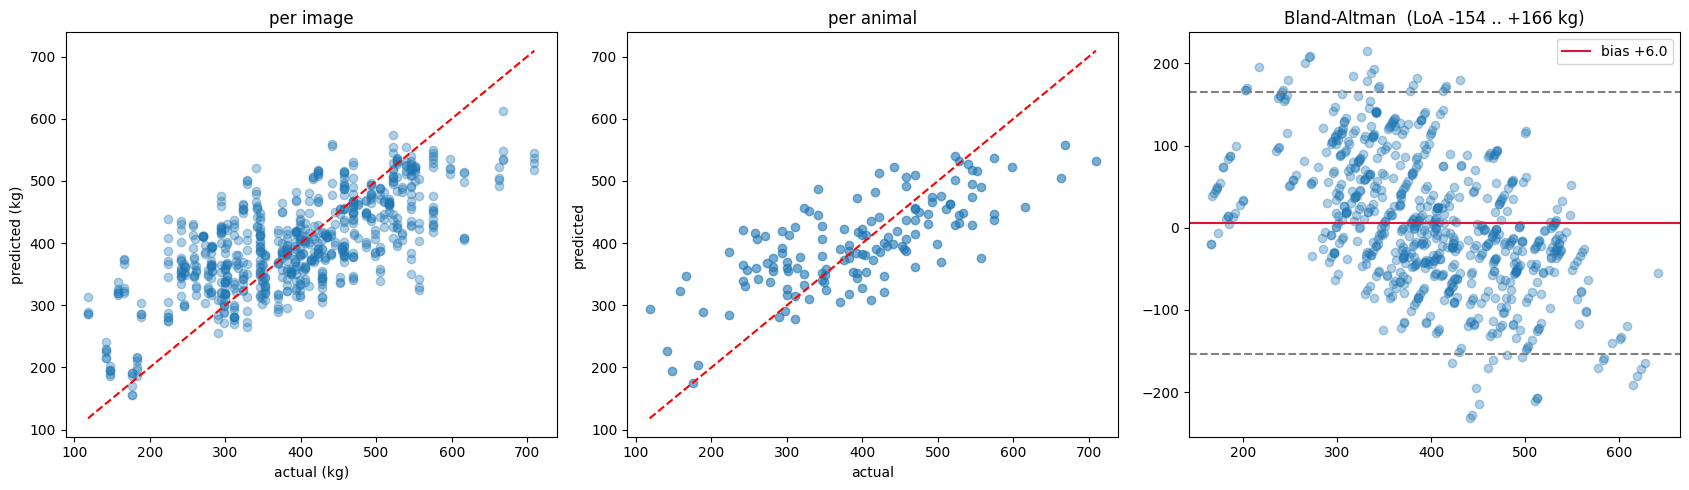

,animal,path,actual,pred,err
468,C054,/content/cow_dataset/train/images/c0054-1_jpg....,557.3,325.3,232.0
538,C054,/content/cow_dataset/train/images/c0054-1_jpg....,557.3,329.6,227.7
598,C024,/content/cow_dataset/train/images/c0024_jpg.rf...,223.6,439.0,215.4
528,C054,/content/cow_dataset/train/images/c0054-1_jpg....,557.3,343.1,214.2
558,C067,/content/cow_dataset/train/images/c0067_jpg.rf...,615.8,405.3,210.5
666,C135,/content/cow_dataset/train/images/C135_jpg.rf....,165.8,374.9,209.2
644,C067,/content/cow_dataset/train/images/c0067_jpg.rf...,615.8,408.3,207.5
26,C135,/content/cow_dataset/train/images/C135_jpg.rf....,165.8,373.1,207.3
485,C067,/content/cow_dataset/train/images/c0067_jpg.rf...,615.8,409.0,206.8
416,C135,/content/cow_dataset/train/images/C135_jpg.rf....,165.8,366.0,200.2


In [87]:
print(f"{'predict-the-mean':<34} MAE {np.abs(y_all-y_all.mean()).mean():6.2f}")
print(f"{'original notebook CNN':<34} MAE  79.91 | RMSE  92.66 | R2 < 0")
print(f"{'round 1 (40 epochs)':<34} MAE  74.01 | RMSE  93.43 | R2  0.347")
print(f"{'round 2 (frozen features)':<34} MAE  78.55 | RMSE  97.09 | R2  0.300")
report(y_all, oof, "THIS RUN")

pa = pd.DataFrame({"a": groups, "y": y_all, "p": oof}).groupby("a").mean()
report(pa["y"], pa["p"], "per-animal (photos averaged)")

fig, ax = plt.subplots(1, 3, figsize=(17, 5))
ax[0].scatter(y_all, oof, alpha=.35)
lim = [y_all.min(), y_all.max()]; ax[0].plot(lim, lim, "r--")
ax[0].set_xlabel("actual (kg)"); ax[0].set_ylabel("predicted (kg)")
ax[0].set_title("per image")

ax[1].scatter(pa["y"], pa["p"], alpha=.6)
ax[1].plot(lim, lim, "r--"); ax[1].set_xlabel("actual"); ax[1].set_ylabel("predicted")
ax[1].set_title("per animal")

d = oof - y_all; bias, s = d.mean(), d.std(ddof=1)
ax[2].scatter((y_all + oof) / 2, d, alpha=.35)
ax[2].axhline(bias, color="crimson", label=f"bias {bias:+.1f}")
ax[2].axhline(bias + 1.96*s, color="gray", ls="--")
ax[2].axhline(bias - 1.96*s, color="gray", ls="--")
ax[2].set_title(f"Bland-Altman  (LoA {bias-1.96*s:+.0f} .. {bias+1.96*s:+.0f} kg)")
ax[2].legend()
plt.tight_layout(); plt.show()

# Where it fails worst - usually informative about capture conditions.
worst = (pd.DataFrame({"animal": groups, "path": dfx["path"], "actual": y_all,
                       "pred": oof, "err": np.abs(oof - y_all)})
         .sort_values("err", ascending=False).head(10))
display(worst.round(1))

In [88]:
def load_ensemble(save_dir=SAVE_DIR):
    man = json.load(open(f"{save_dir}/manifest.json", encoding="utf-8"))
    nets = []
    for f in man["folds"]:
        ck = torch.load(f"{save_dir}/{f['path']}", map_location=DEVICE,
                        weights_only=False)
        net = WeightNet(man["backbone"], len(man["feat_cols"]), man["n_breeds"],
                        len(man["reg_targets"])).to(DEVICE)
        net.load_state_dict(ck["state_dict"]); net.eval()
        nets.append((net, ck["norm"]))
    return man, nets


@torch.no_grad()
def predict_weight(pil_img, geom: dict, man, nets):
    # geom: raw (unstandardised) values, keyed by man['feat_cols']
    tf = transforms.Compose([LetterboxPad(man["img_size"]),
                             transforms.ToTensor(), NORM])
    x = tf(pil_img.convert("RGB")).unsqueeze(0).to(DEVICE)
    v = [(geom[c] - man["geom_stats"][c][0]) / man["geom_stats"][c][1]
         for c in man["feat_cols"]]
    fv = torch.tensor([v], dtype=torch.float32).to(DEVICE)

    out = []
    for net, norm in nets:
        r1, _ = net(x, fv); r2, _ = net(torch.flip(x, dims=[3]), fv)
        z = ((r1 + r2) / 2)[0, 0].item()
        out.append(z * norm["weight"][1] + norm["weight"][0])
    # the spread across folds is a usable confidence signal
    return float(np.mean(out)), float(np.std(out)), out


man, nets = load_ensemble()
row = dfx.iloc[0]
img = Image.open(os.path.join(DATA_FULL, row["path"]))
raw_geom = {c: float(df.loc[row.name, c]) for c in man["feat_cols"]}
w, s, each = predict_weight(img, raw_geom, man, nets)
print(f"actual {row['weight']:.1f} kg | ensemble {w:.1f} +/- {s:.1f} kg")
print("per fold:", [round(v, 1) for v in each])

actual 399.2 kg | ensemble 385.2 +/- 13.0 kg
per fold: [366.1, 402.3, 393.3, 374.7, 389.4]


### Improved Strategy: Feature Ensemble + Regression Ensemble + Multi-Task
* **Features**: ConvNeXt-Tiny + EfficientNetV2-S + Geometry
* **Regressors**: Multi-Task MLP (400 epochs), SVR, Ridge
* **Ensemble**: Average of the three methods.

In [45]:
# 2. Define Multitask MLP for Frozen Features
class FrozenMultitaskMLP(nn.Module):
    def __init__(self, in_features, n_reg=5, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, n_reg)
        )
        self.log_var = nn.Parameter(torch.zeros(n_reg))

    def forward(self, x):
        return self.net(x)

def train_mlp_fold(X_tr, y_tr_all, X_va, y_va_all, epochs=400, batch_size=32, lr=1e-3):
    # Prepare targets (normalized)
    mu_all = y_tr_all.mean(axis=0)
    sd_all = y_tr_all.std(axis=0) + 1e-8
    y_tr_norm = (y_tr_all - mu_all) / sd_all

    ds_tr = TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr_norm, dtype=torch.float32))
    dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True)

    model = FrozenMultitaskMLP(X_tr.shape[1], n_reg=y_tr_all.shape[1]).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    best_mae = 1e9
    best_wts = None

    X_va_t = torch.tensor(X_va, dtype=torch.float32).to(DEVICE)
    y_va_w = y_va_all[:, 0] # weight is the first column

    for ep in range(epochs):
        model.train()
        for x_b, y_b in dl_tr:
            x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
            opt.zero_grad()
            preds = model(x_b)

            # Multitask loss
            loss = 0
            for i in range(preds.shape[1]):
                l_i = F.smooth_l1_loss(preds[:, i], y_b[:, i])
                s = model.log_var[i]
                loss += torch.exp(-s) * l_i + s

            loss.backward()
            opt.step()
        sch.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(X_va_t)[:, 0].cpu().numpy() * sd_all[0] + mu_all[0]
            mae = np.abs(val_preds - y_va_w).mean()
            if mae < best_mae:
                best_mae = mae
                best_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_wts)
    model.eval()
    with torch.no_grad():
        final_preds = model(X_va_t)[:, 0].cpu().numpy() * sd_all[0] + mu_all[0]
    return final_preds

In [34]:
import os
import gc
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold

# เตรียมโฟลเดอร์สำหรับเซฟโมเดลใน Google Drive
SAVE_DIR_ALL = f"{DRIVE}/all_backbones_multitask"
os.makedirs(SAVE_DIR_ALL, exist_ok=True)

# เตรียมข้อมูล (Standardise geometry)
dfx = df.copy()
dfx[GEOM_COLS] = (dfx[GEOM_COLS] - dfx[GEOM_COLS].mean()) / (dfx[GEOM_COLS].std() + 1e-8)

# สร้าง SPLITS สำหรับแบ่งข้อมูล Train / Val
groups = df["animal_id"].to_numpy()
SPLITS = list(GroupKFold(n_splits=8).split(df, groups=groups))

# ใช้ Fold แรกสำหรับการเปรียบเทียบ (ประหยัดเวลา)
tr_i, va_i = SPLITS[0]

BACKBONES = {
    "dinov2_s":  "vit_small_patch14_dinov2.lvd142m",
    "clip_b16":  "vit_base_patch16_clip_224.openai",
    "convnext_t": "convnext_tiny.fb_in22k",
    "effv2_s":   "tf_efficientnetv2_s.in21k",
}

results_all = []

for bb_key, bb_name in BACKBONES.items():
    print(f"\n{'='*60}")
    print(f"Fine-tuning {bb_key} ({bb_name})")
    print(f"Using Multiple Regression Output (Targets: {REG_TARGETS})")
    print(f"{'='*60}")

    # ใช้ train_one ที่มี multitask=True ซึ่งจะสร้าง WeightNet
    # ที่มี Output เป็น Multiple Regression (ทำนาย weight, height, L, age, ratio_lh พร้อมกัน)
    res = train_one(
        dfx.iloc[tr_i], dfx.iloc[va_i],
        backbone=bb_name,
        aug="medium",
        feat_cols=GEOM_COLS,
        crop_mode="none",
        epochs=40,       # แนะนำให้ปรับเป็น 150-200 สำหรับการเทรนจริง
        patience=15,
        multitask=True,  # บังคับใช้ Multiple Regression
        seed=SEED,
        log_every=10
    )

    val_mae = res["best"]
    print(f"\n>>> [Result] {bb_key} Best Val MAE (Weight): {val_mae:.2f} kg\n")

    # บันทึกน้ำหนักของโมเดลที่เทรนเสร็จแล้ว
    save_path = f"{SAVE_DIR_ALL}/{bb_key}_multitask_fold1.pth"
    torch.save({
        'state_dict': res["model"].state_dict(),
        'norm': res["norm"],
        'val_mae': val_mae,
        'backbone': bb_name
    }, save_path)

    results_all.append({
        'Backbone Key': bb_key,
        'Backbone Name': bb_name,
        'Val MAE (Weight)': round(val_mae, 2),
        'Saved Path': save_path
    })

    # คืนหน่วยความจำการ์ดจอ
    del res
    torch.cuda.empty_cache()
    gc.collect()

# สรุปผลการเทรนทั้งหมด
print("\n" + "="*40)
print("Summary of All Backbones (Multiple Regression)")
print("="*40)
res_df = pd.DataFrame(results_all).sort_values("Val MAE (Weight)").reset_index(drop=True)
display(res_df)



Fine-tuning dinov2_s (vit_small_patch14_dinov2.lvd142m)
Using Multiple Regression Output (Targets: ['weight', 'Height_y', 'L_y', 'age_years', 'ratio_lh'])
      ep   1  train  91.58  val 118.77  gap +27.19  best 118.77
      ep  11  train  89.05  val 115.29  gap +26.24  best 104.44
      ep  21  train  85.62  val 107.19  gap +21.57  best 101.27
      ep  31  train  81.72  val 102.99  gap +21.27  best 101.27
      ep  35  train  79.72  val 106.88  gap +27.16  best 101.27
      early stop at ep 35

>>> [Result] dinov2_s Best Val MAE (Weight): 101.27 kg


Fine-tuning clip_b16 (vit_base_patch16_clip_224.openai)
Using Multiple Regression Output (Targets: ['weight', 'Height_y', 'L_y', 'age_years', 'ratio_lh'])


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  599MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

      ep   1  train  91.59  val 118.85  gap +27.25  best 118.85
      ep  11  train  86.93  val 107.14  gap +20.22  best 106.57
      ep  21  train  84.11  val 109.41  gap +25.30  best 104.50
      ep  31  train  80.89  val 106.69  gap +25.80  best 101.55
      ep  40  train  79.06  val 109.29  gap +30.23  best 101.55

>>> [Result] clip_b16 Best Val MAE (Weight): 101.55 kg


Fine-tuning convnext_t (convnext_tiny.fb_in22k)
Using Multiple Regression Output (Targets: ['weight', 'Height_y', 'L_y', 'age_years', 'ratio_lh'])


model.safetensors: reconstructing file:   0%|          |  0.00B /  178MB            

...

      ep   1  train  86.98  val 111.32  gap +24.34  best 111.32
      ep  11  train  14.17  val  83.65  gap +69.48  best  73.60
      ep  18  train   8.74  val  82.45  gap +73.70  best  73.60
      early stop at ep 18

>>> [Result] convnext_t Best Val MAE (Weight): 73.60 kg


Fine-tuning effv2_s (tf_efficientnetv2_s.in21k)
Using Multiple Regression Output (Targets: ['weight', 'Height_y', 'L_y', 'age_years', 'ratio_lh'])


model.safetensors: reconstructing file:   0%|          |  0.00B /  193MB            

model.safetensors: downloading bytes:           |  0.00B            

      ep   1  train  74.18  val 103.10  gap +28.91  best 103.10
      ep  11  train  17.20  val  90.12  gap +72.93  best  73.88
      ep  21  train  10.99  val  84.79  gap +73.80  best  73.88
      early stop at ep 21

>>> [Result] effv2_s Best Val MAE (Weight): 73.88 kg


Summary of All Backbones (Multiple Regression)


,Backbone Key,Backbone Name,Val MAE (Weight),Saved Path
0,convnext_t,convnext_tiny.fb_in22k,73.60,/content/drive/MyDrive/KSU/Research/SmartWeigh...
1,effv2_s,tf_efficientnetv2_s.in21k,73.88,/content/drive/MyDrive/KSU/Research/SmartWeigh...
2,dinov2_s,vit_small_patch14_dinov2.lvd142m,101.27,/content/drive/MyDrive/KSU/Research/SmartWeigh...
3,clip_b16,vit_base_patch16_clip_224.openai,101.55,/content/drive/MyDrive/KSU/Research/SmartWeigh...


In [41]:
import os

drive_path = '/content/drive/MyDrive/KSU/Research/SmartWeight'
expected_features = [
    'feat_dinov2_s_none.npy',
    'feat_clip_b16_none.npy',
    'feat_convnext_t_none.npy',
    'feat_effv2_s_none.npy',
    'feat_convnext_t_context.npy',
    'feat_effv2_s_context.npy'
]

print(f"กำลังตรวจสอบไฟล์ใน: {drive_path}")
if os.path.exists(drive_path):
    found_files = os.listdir(drive_path)
    missing = False
    for f in expected_features:
        if f in found_files:
            print(f"✅ พบไฟล์: {f}")
        else:
            print(f"❌ ไม่พบไฟล์: {f}")
            missing = True
    if missing:
        print("\nไฟล์ Features ใน Google Drive ยังไม่ครบ คุณอาจต้องคัดลอกจาก /content/ หรือรันการดึง Features ใหม่แล้วบันทึกลง Drive")
else:
    print("ไม่พบโฟลเดอร์ใน Google Drive โปรดตรวจสอบ path อีกครั้ง")

กำลังตรวจสอบไฟล์ใน: /content/drive/MyDrive/KSU/Research/SmartWeight
❌ ไม่พบไฟล์: feat_dinov2_s_none.npy
❌ ไม่พบไฟล์: feat_clip_b16_none.npy
❌ ไม่พบไฟล์: feat_convnext_t_none.npy
❌ ไม่พบไฟล์: feat_effv2_s_none.npy
❌ ไม่พบไฟล์: feat_convnext_t_context.npy
❌ ไม่พบไฟล์: feat_effv2_s_context.npy

ไฟล์ Features ใน Google Drive ยังไม่ครบ คุณอาจต้องคัดลอกจาก /content/ หรือรันการดึง Features ใหม่แล้วบันทึกลง Drive


In [44]:
import os
import torch
import numpy as np
from torch.utils.data import DataLoader

# เตรียม Dictionary สำหรับเก็บ Features
if 'FEATS' not in globals():
    FEATS = {}

target_models = ['convnext_t', 'effv2_s', 'dinov2_s', 'clip_b16']

def extract_features_from_finetuned(bb_key, bb_name):
    print(f"\nExtracting features from fine-tuned {bb_key}...")
    save_path = f"{SAVE_DIR_ALL}/{bb_key}_multitask_fold1.pth"
    if not os.path.exists(save_path):
        print(f"❌ File not found: {save_path}")
        return None

    # โหลด Checkpoint
    ckpt = torch.load(save_path, map_location=DEVICE, weights_only=False)

    # สร้างโมเดล WeightNet เเละโหลด Weights
    model = WeightNet(backbone=bb_name, n_feats=len(GEOM_COLS),
                      n_breeds=N_BREEDS, n_reg=len(REG_TARGETS), multitask=True).to(DEVICE)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()

    # สร้าง DataLoader สำหรับดึง Features
    norm = ckpt['norm']
    mk = lambda s, tf: CowDataset(s, DATA_FULL, tf, crop_mode="none", feat_cols=GEOM_COLS, norm=norm)
    dl = DataLoader(mk(dfx, EVAL_TF_F), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    out = []
    with torch.no_grad():
        for x, f_, yv, m, b in dl:
            x = x.to(DEVICE)
            # ใช้เทคนิค TTA (Flip) เหมือนตอน Inference
            f1 = model.backbone(x)
            f2 = model.backbone(torch.flip(x, dims=[3]))
            feats = (f1 + f2) / 2
            out.append(feats.cpu().numpy())

    return np.concatenate(out)

# ดึง Features เเละบันทึก
for bb_key, bb_name in BACKBONES.items():
    if bb_key in target_models:
        feats = extract_features_from_finetuned(bb_key, bb_name)
        if feats is not None:
            FEATS[f"{bb_key}|none"] = feats
            np.save(f"/content/feat_{bb_key}_none.npy", feats)
            print(f"✅ Saved features for {bb_key} with shape {feats.shape}")

# สร้าง X_concat สำหรับนำไปทำ Ensemble
if all(f"{m}|none" in FEATS for m in target_models):
    f_conv = FEATS["convnext_t|none"]
    f_eff = FEATS["effv2_s|none"]
    f_dino = FEATS["dinov2_s|none"]
    f_clip = FEATS["clip_b16|none"]
    GEOM_FEATURES = dfx[GEOM_COLS].to_numpy(float)
    X_concat = np.hstack([f_conv, f_eff, f_dino, f_clip, GEOM_FEATURES])
    print(f"\n🎉 Combined features shape (X_concat): {X_concat.shape}")
    print("พร้อมสำหรับการเทรน Ensemble แล้วครับ (สามารถรันเซลล์ Ensemble ต่อได้เลย)")
else:
    print("\n⚠️ ไม่สามารถสร้าง X_concat ได้เนื่องจากดึง Features ได้ไม่ครบ")


Extracting features from fine-tuned dinov2_s...
✅ Saved features for dinov2_s with shape (728, 384)

Extracting features from fine-tuned clip_b16...
✅ Saved features for clip_b16 with shape (728, 768)

Extracting features from fine-tuned convnext_t...
✅ Saved features for convnext_t with shape (728, 768)

Extracting features from fine-tuned effv2_s...
✅ Saved features for effv2_s with shape (728, 1280)

🎉 Combined features shape (X_concat): (728, 3208)
พร้อมสำหรับการเทรน Ensemble แล้วครับ (สามารถรันเซลล์ Ensemble ต่อได้เลย)


### 3. Run Ensemble (5-Fold CV)
Train SVR, Ridge, and Multi-Task MLP on the concatenated features, then average their predictions.

In [46]:
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.svm import SVR
import numpy as np

# 1. Prepare Targets and Groups
y_weight = df["weight"].to_numpy(float)
groups = df["animal_id"].to_numpy()

# All regression targets for MLP
y_multi = df[REG_TARGETS].to_numpy(float)
# Fill NaNs with column means for simplicity in MLP targets
for j in range(y_multi.shape[1]):
    mask = np.isnan(y_multi[:, j])
    y_multi[mask, j] = np.nanmean(y_multi[:, j])

# 2. Setup 5-Fold CV
gkf = GroupKFold(n_splits=5)
splits = list(gkf.split(X_concat, groups=groups))

preds_svr = np.zeros(len(df))
preds_ridge = np.zeros(len(df))
preds_mlp = np.zeros(len(df))

print("Training Ensemble Models...")
for k, (tr_i, va_i) in enumerate(splits, 1):
    print(f"\nFold {k}/5")
    X_tr, X_va = X_concat[tr_i], X_concat[va_i]
    y_tr_w, y_va_w = y_weight[tr_i], y_weight[va_i]

    # SVR
    print("  Training SVR...")
    m_svr = make_pipeline(StandardScaler(), SVR(C=100, epsilon=5))
    m_svr.fit(X_tr, y_tr_w)
    preds_svr[va_i] = m_svr.predict(X_va)

    # Ridge
    print("  Training Ridge...")
    m_ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 5, 40)))
    m_ridge.fit(X_tr, y_tr_w)
    preds_ridge[va_i] = m_ridge.predict(X_va)

    # MLP (400 epochs)
    print("  Training Multi-Task MLP (400 epochs)...")
    y_tr_multi, y_va_multi = y_multi[tr_i], y_multi[va_i]
    preds_mlp[va_i] = train_mlp_fold(X_tr, y_tr_multi, X_va, y_va_multi, epochs=400)

# 3. Average predictions
preds_ensemble = (preds_svr + preds_ridge + preds_mlp) / 3

print("\n" + "="*50)
print("Ensemble Results (Out-of-Fold)")
print("="*50)
report(y_weight, preds_svr, "SVR Only")
report(y_weight, preds_ridge, "Ridge Only")
report(y_weight, preds_mlp, "MLP Only")
print("-"*50)
report(y_weight, preds_ensemble, "Average Ensemble")


Training Ensemble Models...

Fold 1/5
  Training SVR...
  Training Ridge...
  Training Multi-Task MLP (400 epochs)...

Fold 2/5
  Training SVR...
  Training Ridge...
  Training Multi-Task MLP (400 epochs)...

Fold 3/5
  Training SVR...
  Training Ridge...
  Training Multi-Task MLP (400 epochs)...

Fold 4/5
  Training SVR...
  Training Ridge...
  Training Multi-Task MLP (400 epochs)...

Fold 5/5
  Training SVR...
  Training Ridge...
  Training Multi-Task MLP (400 epochs)...

Ensemble Results (Out-of-Fold)
SVR Only                           MAE  34.32 | RMSE  51.44 | MAPE 10.99% | R2  0.802 | bias   +2.4 | <=10%  71.4%
Ridge Only                         MAE  31.35 | RMSE  44.16 | MAPE  9.64% | R2  0.854 | bias   +1.7 | <=10%  69.9%
MLP Only                           MAE  25.82 | RMSE  38.45 | MAPE  8.03% | R2  0.889 | bias   +2.2 | <=10%  79.7%
--------------------------------------------------
Average Ensemble                   MAE  28.22 | RMSE  41.22 | MAPE  8.92% | R2  0.873 | bias  

{'n': 728,
 'MAE': np.float64(28.220730980015755),
 'RMSE': np.float64(41.21820712694544),
 'MAPE': np.float64(8.916869005618361),
 'R2': np.float64(0.8729793874570386),
 'bias': np.float64(2.0813487100257237),
 'within10': np.float64(77.06043956043956)}

In [48]:
# Data Leakage Check
# ตรวจสอบว่ามีสัตว์ตัวเดียวกัน (animal_id) โผล่ไปทั้งใน Train และ Val set หรือไม่
print("Checking for Data Leakage (Animal ID overlap between Train and Val)...")

leakage_found = False
for k, (tr_i, va_i) in enumerate(SPLITS, 1):
    tr_animals = set(df.iloc[tr_i]['animal_id'])
    va_animals = set(df.iloc[va_i]['animal_id'])
    overlap = tr_animals.intersection(va_animals)

    print(f"Fold {k}: {len(overlap)} overlapping animals.")
    if len(overlap) > 0:
        leakage_found = True
        print(f"  [!] Warning: Leakage detected in Fold {k}! Overlapping IDs: {overlap}")

if not leakage_found:
    print("\n✅ Data Leakage check complete: No leakage detected. GroupKFold is working correctly.")
else:
    print("\n❌ Data Leakage detected! Please review the splitting strategy.")

Checking for Data Leakage (Animal ID overlap between Train and Val)...
Fold 1: 0 overlapping animals.
Fold 2: 0 overlapping animals.
Fold 3: 0 overlapping animals.
Fold 4: 0 overlapping animals.
Fold 5: 0 overlapping animals.
Fold 6: 0 overlapping animals.
Fold 7: 0 overlapping animals.
Fold 8: 0 overlapping animals.

✅ Data Leakage check complete: No leakage detected. GroupKFold is working correctly.


In [49]:
from sklearn.linear_model import LinearRegression

# เตรียมฟีเจอร์สำหรับ Meta-learner โดยนำ OOF predictions จากโมเดลทั้ง 3 มารวมกัน
X_stack = np.column_stack([preds_svr, preds_ridge, preds_mlp])

preds_stacked = np.zeros(len(df))

print("Training Stacked Ensemble (Meta-Learner: Linear Regression)...")
# ทำ Cross-Validation สำหรับ Meta-learner ด้วย Split เดิม
for k, (tr_i, va_i) in enumerate(splits, 1):
    X_stack_tr, X_stack_va = X_stack[tr_i], X_stack[va_i]
    y_tr_w, y_va_w = y_weight[tr_i], y_weight[va_i]

    # ใช้ Linear Regression เป็น Meta-learner
    meta_model = LinearRegression()
    meta_model.fit(X_stack_tr, y_tr_w)
    preds_stacked[va_i] = meta_model.predict(X_stack_va)

print("\n" + "="*72)
print("Comparison: Average Ensemble vs Stacked Ensemble")
print("="*72)
report(y_weight, preds_ensemble, "Average Ensemble")
print("-"*72)
report(y_weight, preds_stacked, "Stacked Ensemble (Linear Meta-Learner)")
print("="*72)

# ดึงค่าน้ำหนัก (Coefficients) จาก Fold สุดท้ายมาดูว่า Meta-learner ให้น้ำหนักโมเดลไหนเท่าไหร่
print("\nMeta-learner coefficients (from last fold):")
print(f"  SVR Weight   : {meta_model.coef_[0]:.4f}")
print(f"  Ridge Weight : {meta_model.coef_[1]:.4f}")
print(f"  MLP Weight   : {meta_model.coef_[2]:.4f}")
print(f"  Intercept    : {meta_model.intercept_:.4f}")

Training Stacked Ensemble (Meta-Learner: Linear Regression)...

Comparison: Average Ensemble vs Stacked Ensemble
Average Ensemble                   MAE  28.22 | RMSE  41.22 | MAPE  8.92% | R2  0.873 | bias   +2.1 | <=10%  77.1%
------------------------------------------------------------------------
Stacked Ensemble (Linear Meta-Learner) MAE  26.45 | RMSE  39.04 | MAPE  8.17% | R2  0.886 | bias   -0.3 | <=10%  79.4%

Meta-learner coefficients (from last fold):
  SVR Weight   : -0.0595
  Ridge Weight : -0.0578
  MLP Weight   : 1.0898
  Intercept    : 8.3036


In [50]:
# กรองข้อมูลเฉพาะภาพที่มาจากโฟลเดอร์ 'test'
test_mask = df['category'] == 'test'
y_test = y_weight[test_mask]
preds_test_stacked = preds_stacked[test_mask]
preds_test_avg = preds_ensemble[test_mask]

print("="*72)
print(f"Performance on YOLO 'test' set only (N={test_mask.sum()} images)")
print("="*72)
report(y_test, preds_test_avg, "Average Ensemble (Test Set)")
print("-"*72)
report(y_test, preds_test_stacked, "Stacked Ensemble (Test Set)")
print("="*72)

# สร้าง DataFrame เพื่อดูผลลัพธ์รายตัว
test_results = df[test_mask].copy()
test_results['Predicted_Weight'] = preds_test_stacked
test_results['Error (kg)'] = np.abs(test_results['weight'] - test_results['Predicted_Weight'])

# แสดง 10 อันดับแรก
print("\nตัวอย่างผลการทำนายบน Test Set:")
display(test_results[['ID', 'animal_id', 'Category', 'weight', 'Predicted_Weight', 'Error (kg)']].head(10).round(2))

# หาค่าเฉลี่ยต่อตัวสัตว์ (Per-Animal) ใน Test set
pa_test = test_results.groupby('animal_id').agg({
    'weight': 'mean',
    'Predicted_Weight': 'mean'
}).reset_index()

print("\n" + "="*72)
print(f"Per-Animal Performance on Test Set (N={len(pa_test)} animals)")
print("="*72)
report(pa_test['weight'], pa_test['Predicted_Weight'], "Stacked Ensemble (Per-Animal)")

Performance on YOLO 'test' set only (N=28 images)
Average Ensemble (Test Set)        MAE  30.15 | RMSE  39.30 | MAPE  7.58% | R2  0.860 | bias  -10.8 | <=10%  75.0%
------------------------------------------------------------------------
Stacked Ensemble (Test Set)        MAE  26.01 | RMSE  34.74 | MAPE  6.79% | R2  0.890 | bias  -10.9 | <=10%  75.0%

ตัวอย่างผลการทำนายบน Test Set:


,ID,animal_id,Category,weight,Predicted_Weight,Error (kg)
700,C002,C002,บราห์มัน/ลูกผสมบราห์มัน,382.00,382.40,0.40
701,C099,C099,บราห์มัน/ลูกผสมบราห์มัน,469.45,469.33,0.12
702,C007,C007,บราห์มัน/ลูกผสมบราห์มัน,350.00,329.48,20.52
703,C047,C047,บราห์มัน/ลูกผสมบราห์มัน,457.74,430.17,27.57
704,C107,C107,ลูกผสมแบรงกัส/แองกัส,410.91,327.23,83.67
705,C103,C103,ลูกผสมแบรงกัส/แองกัส,317.24,332.51,15.27
706,C046,C046,บราห์มัน/ลูกผสมบราห์มัน,241.93,261.93,20.00
707,C084,C084,บราห์มัน/ลูกผสมบราห์มัน,323.10,317.49,5.60
708,C071,C071,บราห์มัน/ลูกผสมบราห์มัน,574.82,573.02,1.80
709,C032,C032,บราห์มัน/ลูกผสมบราห์มัน,299.68,260.48,39.20



Per-Animal Performance on Test Set (N=27 animals)
Stacked Ensemble (Per-Animal)      MAE  24.36 | RMSE  32.47 | MAPE  6.41% | R2  0.908 | bias   -8.7 | <=10%  77.8%


{'n': 27,
 'MAE': np.float64(24.357333583354823),
 'RMSE': np.float64(32.46857476250987),
 'MAPE': np.float64(6.408194029590765),
 'R2': np.float64(0.9076632855224503),
 'bias': np.float64(-8.690373182980869),
 'within10': np.float64(77.77777777777779)}